# Phishing URL Detection - Enhanced Analysis
## Models: XGBoost, CatBoost, KNN, Random Forest, Decision Tree
### With Incremental Data Partitions (40%, 50%, 60%, 70%, 80%) and Epoch Testing (20, 40, 60)

## 1. Loading the Data

In [ ]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Loading data into dataframe
data = pd.read_csv("dataset_cybersecurity_michelle.csv")
print(f"Dataset loaded successfully!")
print(f"Shape: {data.shape}")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Dataset loaded successfully!
Shape: (129698, 112)
Rows: 129698, Columns: 112


## 2. Familiarizing with Data & EDA

In [ ]:
# Display first few rows
print("First 5 rows of the dataset:")
data.head()

First 5 rows of the dataset:


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,1,0,0,1,0,0,0,0,0,0,...,2,2,5,292,0,-1,0,0,0,1
1,2,5,4,2,0,0,0,0,0,0,...,2,4,2,52,0,1,0,0,0,1
2,2,0,0,0,0,0,0,0,0,0,...,2,2,0,298,1,1,0,0,0,0
3,1,1,0,2,0,0,0,0,0,0,...,1,2,5,1792,0,0,0,0,0,1
4,2,1,0,0,0,0,0,0,0,0,...,1,2,1,299,1,1,0,0,0,0


In [ ]:
# Dataset information
print("Dataset Info:")
data.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129698 entries, 0 to 129697
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 110.8 MB


In [ ]:
# Statistical summary
print("Statistical Description:")
data.describe().T

Statistical Description:


,count,mean,std,min,25%,50%,75%,max
qty_dot_url,129698.0,2.220612,1.314717,1.0,2.0,2.0,2.0,24.0
qty_hyphen_url,129698.0,0.370044,1.199731,0.0,0.0,0.0,0.0,35.0
qty_underline_url,129698.0,0.132392,0.706240,0.0,0.0,0.0,0.0,21.0
qty_slash_url,129698.0,1.489892,1.963822,0.0,0.0,1.0,3.0,44.0
qty_questionmark_url,129698.0,0.010956,0.123975,0.0,0.0,0.0,0.0,9.0
...,...,...,...,...,...,...,...,...
qty_redirects,129698.0,0.332341,0.793889,-1.0,0.0,0.0,1.0,17.0
url_google_index,129698.0,0.001365,0.052740,-1.0,0.0,0.0,0.0,1.0
domain_google_index,129698.0,0.002051,0.058474,-1.0,0.0,0.0,0.0,1.0
url_shortened,129698.0,0.006369,0.079550,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Check for missing values
print("Missing Values:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing Values:
qty_dot_url             0
qty_hyphen_url          0
qty_underline_url       0
qty_slash_url           0
qty_questionmark_url    0
                       ..
qty_redirects           0
url_google_index        0
domain_google_index     0
url_shortened           0
phishing                0
Length: 112, dtype: int64

Total missing values: 0


In [ ]:
# Unique values per column
print("Unique values in each column:")
print(data.nunique())

Unique values in each column:
qty_dot_url             23
qty_hyphen_url          30
qty_underline_url       22
qty_slash_url           25
qty_questionmark_url     6
                        ..
qty_redirects           15
url_google_index         3
domain_google_index      3
url_shortened            2
phishing                 2
Length: 112, dtype: int64


## 3. Visualizing the Data

### a. Heatmap of Top 20 Features

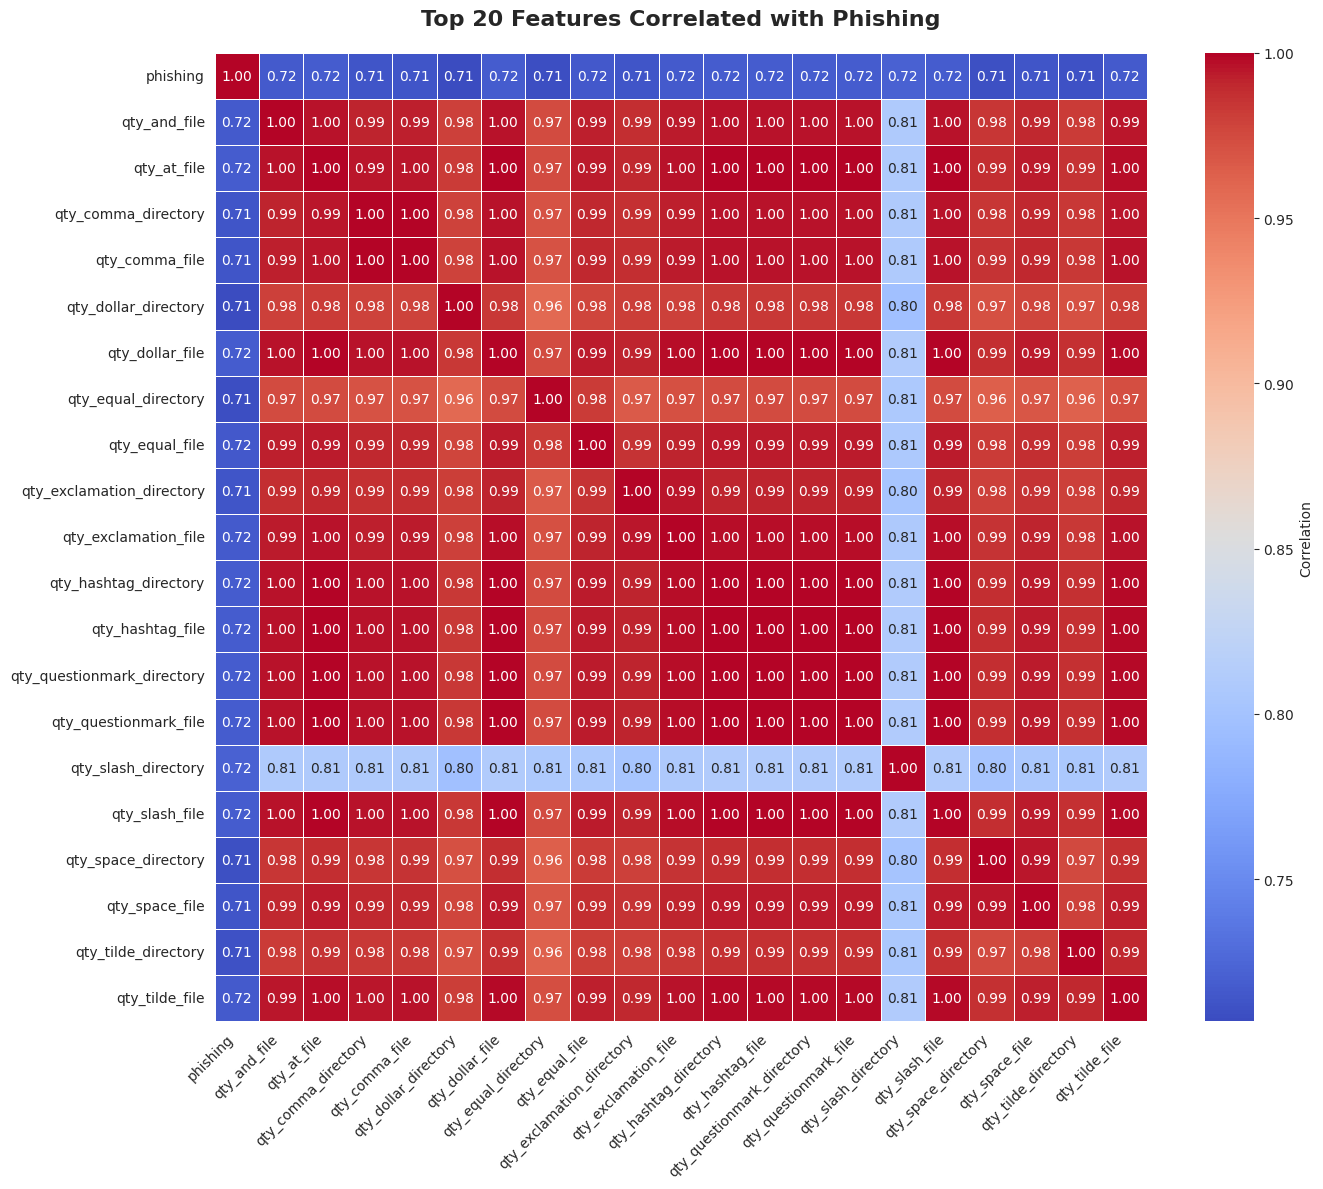


Top 20 Features by Correlation with Target:
qty_slash_directory           0.721240
qty_questionmark_directory    0.717482
qty_questionmark_file         0.717482
qty_slash_file                0.717482
qty_dollar_file               0.717482
qty_hashtag_file              0.717482
qty_hashtag_directory         0.717482
qty_at_file                   0.717317
qty_exclamation_file          0.716787
qty_and_file                  0.716564
qty_tilde_file                0.716252
qty_equal_file                0.715249
qty_space_file                0.713765
qty_comma_file                0.713531
qty_exclamation_directory     0.713470
qty_comma_directory           0.713385
qty_tilde_directory           0.710626
qty_space_directory           0.710308
qty_equal_directory           0.708810
qty_dollar_directory          0.706977
Name: phishing, dtype: float64


In [ ]:
# Calculate correlation matrix
corr_matrix = data.corr()

# Get absolute correlation with target variable 'phishing'
target_corr = corr_matrix['phishing'].abs().sort_values(ascending=False)

# Select top 20 features (excluding target itself)
top_features = target_corr[1:21].index

# Create correlation matrix for top features
top_corr_matrix = data[top_features.union(['phishing'])].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            cbar_kws={'label': 'Correlation'}, linewidths=0.5)
plt.title('Top 20 Features Correlated with Phishing', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nTop 20 Features by Correlation with Target:")
print(target_corr[1:21])

### b. Pie Chart - Distribution of Phishing vs Legitimate URLs

Class Distribution:
phishing
0    77546
1    52152
Name: count, dtype: int64

Percentage Distribution:
phishing
0    59.789665
1    40.210335
Name: proportion, dtype: float64


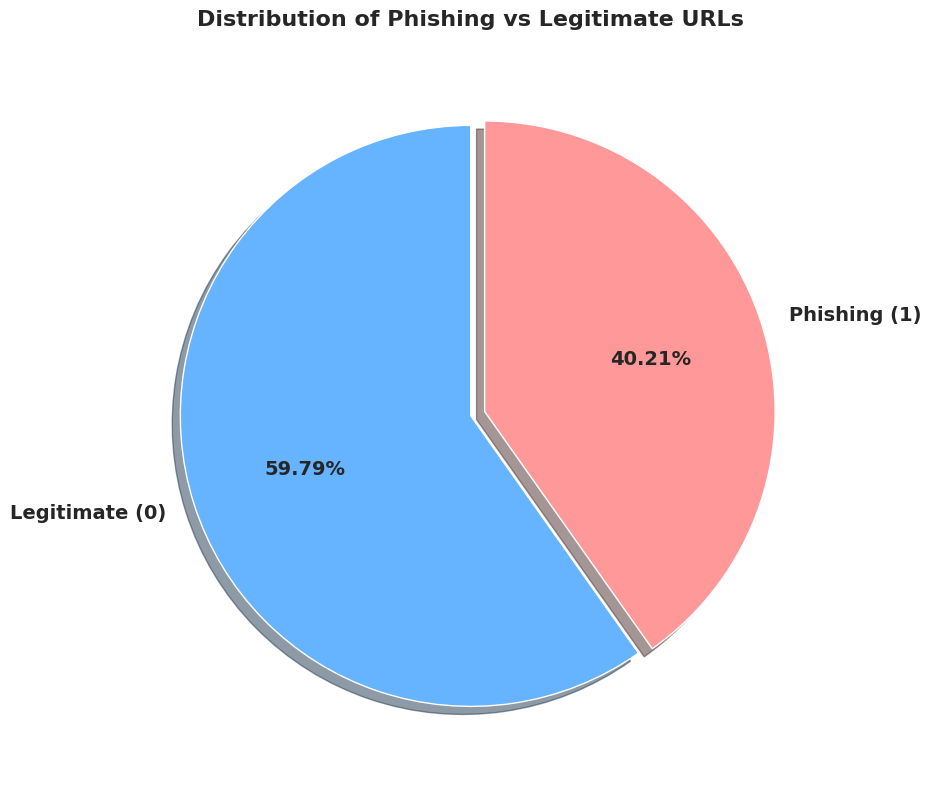

In [ ]:
# Count distribution
print("Class Distribution:")
print(data['phishing'].value_counts())
print(f"\nPercentage Distribution:")
print(data['phishing'].value_counts(normalize=True) * 100)

# Create pie chart
labels = ['Legitimate (0)', 'Phishing (1)']
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(10, 8))
data['phishing'].value_counts().plot(
    kind='pie',
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.05),
    shadow=True,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
plt.title("Distribution of Phishing vs Legitimate URLs", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Splitting the Data

In [ ]:
# Split features and target
X = data.drop(['phishing'], axis=1)
y = data['phishing']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (129698, 111)
Target shape: (129698,)


In [ ]:
# Train-test split: 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples ({(X_train.shape[0]/len(X))*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({(X_test.shape[0]/len(X))*100:.1f}%)")
print(f"\nTest set remains fixed for all experiments")

Training set: 103758 samples (80.0%)
Test set: 25940 samples (20.0%)

Test set remains fixed for all experiments


## 5. Training the Data

### Configuration for Incremental Training & Convergence Analysis

In [ ]:
# Define data partitions and epochs/iterations
DATA_FRACTIONS = [0.4, 0.5, 0.6, 0.7, 0.8]
EPOCHS = [20, 40, 60]

def get_data_fraction(X, y, fraction):
    """
    Get a fraction of TOTAL data from the training set.

    Since training set is 80% of total data, we need to adjust:
    - To get 40% of total → need 50% of training set (0.4/0.8 = 0.5)
    - To get 80% of total → need 100% of training set (0.8/0.8 = 1.0)

    Args:
        X: Training features (80% of total data)
        y: Training labels
        fraction: Target fraction of TOTAL dataset (0.4, 0.5, 0.6, 0.7, 0.8)

    Returns:
        X_frac, y_frac: Subset representing 'fraction' of total data
    """
    from sklearn.model_selection import train_test_split

    # Calculate what fraction of training set we need
    # Training set is 80% of total, so scale up
    train_slice_ratio = fraction / 0.8

    # If we need 100% or more of training set, use all of it
    if train_slice_ratio >= 1.0:
        return X, y
    else:
        # Use stratified sampling to maintain class distribution
        X_frac, _, y_frac, _ = train_test_split(
            X, y,
            train_size=train_slice_ratio,
            random_state=42,
            stratify=y  # Maintains class balance
        )
        return X_frac, y_frac

def train_and_evaluate(model, X_train_frac, y_train_frac, X_test, y_test):
    """Train model and return test accuracy"""
    model.fit(X_train_frac, y_train_frac)
    y_pred = model.predict(X_test)
    return metrics.accuracy_score(y_test, y_pred)

print("="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"Data Partitions: {[f'{int(f*100)}%' for f in DATA_FRACTIONS]}")
print(f"  (These represent % of TOTAL dataset)")
print(f"Epochs/Iterations: {EPOCHS}")
print(f"Models to train: XGBoost, CatBoost, KNN, Random Forest, Decision Tree")
print("="*70)

# Verify the function works correctly
print("\n📊 Verification:")
print(f"Total dataset size: {len(data)}")
print(f"Training set: {len(X_train)} samples (80% of total)")
print(f"Test set: {len(X_test)} samples (20% of total)\n")

for frac in DATA_FRACTIONS:
    X_frac, y_frac = get_data_fraction(X_train, y_train, frac)
    actual_percent = (len(X_frac) / len(data)) * 100
    print(f"{int(frac*100)}% target → {len(X_frac)} samples ({actual_percent:.1f}% of total) ✅")

TRAINING CONFIGURATION
Data Partitions: ['40%', '50%', '60%', '70%', '80%']
  (These represent % of TOTAL dataset)
Epochs/Iterations: [20, 40, 60]
Models to train: XGBoost, CatBoost, KNN, Random Forest, Decision Tree

📊 Verification:
Total dataset size: 129698
Training set: 103758 samples (80% of total)
Test set: 25940 samples (20% of total)

40% target → 51879 samples (40.0% of total) ✅
50% target → 64848 samples (50.0% of total) ✅
60% target → 77818 samples (60.0% of total) ✅
70% target → 90788 samples (70.0% of total) ✅
80% target → 103758 samples (80.0% of total) ✅


### 5.1 XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

print("="*70)
print("TRAINING: XGBoost")
print("="*70 + "\n")

xgb_results = []

for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    print(f"Training with {int(fraction*100)}% data ({len(X_train_frac)} samples):")

    for n_estimators in EPOCHS:
        model = XGBClassifier(
            n_estimators=n_estimators,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )

        accuracy = train_and_evaluate(model, X_train_frac, y_train_frac, X_test, y_test)

        xgb_results.append({
            'Model': 'XGBoost',
            'Data Partition': f"{int(fraction*100)}%",
            'Epochs': n_estimators,
            'Accuracy': accuracy
        })

        print(f"  Estimators: {n_estimators:2d} → Accuracy: {accuracy:.4f}")

xgb_df = pd.DataFrame(xgb_results)
print("\n✓ XGBoost training completed!\n")

TRAINING: XGBoost

Training with 40% data (51879 samples):
  Estimators: 20 → Accuracy: 0.9572
  Estimators: 40 → Accuracy: 0.9625
  Estimators: 60 → Accuracy: 0.9657
Training with 50% data (64848 samples):
  Estimators: 20 → Accuracy: 0.9578
  Estimators: 40 → Accuracy: 0.9633
  Estimators: 60 → Accuracy: 0.9671
Training with 60% data (77818 samples):
  Estimators: 20 → Accuracy: 0.9582
  Estimators: 40 → Accuracy: 0.9633
  Estimators: 60 → Accuracy: 0.9672
Training with 70% data (90788 samples):
  Estimators: 20 → Accuracy: 0.9585
  Estimators: 40 → Accuracy: 0.9640
  Estimators: 60 → Accuracy: 0.9664
Training with 80% data (103758 samples):
  Estimators: 20 → Accuracy: 0.9588
  Estimators: 40 → Accuracy: 0.9643
  Estimators: 60 → Accuracy: 0.9667

✓ XGBoost training completed!



In [ ]:
# Train XGBoost on full 80% data with best epochs for final metrics
print("Training XGBoost on full 80% training data...")
xgb_final = XGBClassifier(n_estimators=60, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_final.fit(X_train, y_train)

y_pred_xgb = xgb_final.predict(X_test)
y_train_pred_xgb = xgb_final.predict(X_train)

xgb_metrics = {
    'Model': 'XGBoost',
    'Accuracy': metrics.accuracy_score(y_test, y_pred_xgb),
    'F1-Score': metrics.f1_score(y_test, y_pred_xgb),
    'Recall': metrics.recall_score(y_test, y_pred_xgb),
    'Precision': metrics.precision_score(y_test, y_pred_xgb)
}

print("✓ XGBoost final model trained!")

Training XGBoost on full 80% training data...
✓ XGBoost final model trained!


### 5.2 CatBoost Classifier

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

print("="*70)
print("TRAINING: CatBoost")
print("="*70 + "\n")

cat_results = []

for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    print(f"Training with {int(fraction*100)}% data ({len(X_train_frac)} samples):")

    for n_iterations in EPOCHS:
        model = CatBoostClassifier(
            iterations=n_iterations,
            learning_rate=0.1,
            random_state=42,
            verbose=False
        )

        accuracy = train_and_evaluate(model, X_train_frac, y_train_frac, X_test, y_test)

        cat_results.append({
            'Model': 'CatBoost',
            'Data Partition': f"{int(fraction*100)}%",
            'Epochs': n_iterations,
            'Accuracy': accuracy
        })

        print(f"  Iterations: {n_iterations:2d} → Accuracy: {accuracy:.4f}")

cat_df = pd.DataFrame(cat_results)
print("\n✓ CatBoost training completed!\n")

TRAINING: CatBoost

Training with 40% data (51879 samples):
  Iterations: 20 → Accuracy: 0.9366
  Iterations: 40 → Accuracy: 0.9458
  Iterations: 60 → Accuracy: 0.9497
Training with 50% data (64848 samples):
  Iterations: 20 → Accuracy: 0.9374
  Iterations: 40 → Accuracy: 0.9468
  Iterations: 60 → Accuracy: 0.9504
Training with 60% data (77818 samples):
  Iterations: 20 → Accuracy: 0.9359
  Iterations: 40 → Accuracy: 0.9460
  Iterations: 60 → Accuracy: 0.9497
Training with 70% data (90788 samples):
  Iterations: 20 → Accuracy: 0.9381
  Iterations: 40 → Accuracy: 0.9468
  Iterations: 60 → Accuracy: 0.9501
Training with 80% data (103758 samples):
  Iterations: 20 → Accuracy: 0.9392
  Iterations: 40 → Accuracy: 0.9475
  Iterations: 60 → Accuracy: 0.9516

✓ CatBoost training completed!



In [ ]:
# Train CatBoost on full 80% data
print("Training CatBoost on full 80% training data...")
cat_final = CatBoostClassifier(iterations=60, learning_rate=0.1, random_state=42, verbose=False)
cat_final.fit(X_train, y_train)

y_pred_cat = cat_final.predict(X_test)
y_train_pred_cat = cat_final.predict(X_train)

cat_metrics = {
    'Model': 'CatBoost',
    'Accuracy': metrics.accuracy_score(y_test, y_pred_cat),
    'F1-Score': metrics.f1_score(y_test, y_pred_cat),
    'Recall': metrics.recall_score(y_test, y_pred_cat),
    'Precision': metrics.precision_score(y_test, y_pred_cat)
}

print("✓ CatBoost final model trained!")

Training CatBoost on full 80% training data...
✓ CatBoost final model trained!


### 5.3 K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("="*70)
print("TRAINING: KNN")
print("="*70 + "\n")

knn_results = []

for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    print(f"Training with {int(fraction*100)}% data ({len(X_train_frac)} samples):")

    for n_neighbors in EPOCHS:
        pipeline_knn = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=20)),
            ('knn', KNeighborsClassifier(n_neighbors=n_neighbors))
        ])

        pipeline_knn.fit(X_train_frac, y_train_frac)
        y_pred = pipeline_knn.predict(X_test)
        accuracy = metrics.accuracy_score(y_test, y_pred)

        knn_results.append({
            'Model': 'KNN',
            'Data Partition': f"{int(fraction*100)}%",
            'Epochs': n_neighbors,
            'Accuracy': accuracy
        })

        print(f"  Neighbors: {n_neighbors:2d} → Accuracy: {accuracy:.4f}")

knn_df = pd.DataFrame(knn_results)
print("\n✓ KNN training completed!\n")

TRAINING: KNN

Training with 40% data (51879 samples):
  Neighbors: 20 → Accuracy: 0.9389
  Neighbors: 40 → Accuracy: 0.9326
  Neighbors: 60 → Accuracy: 0.9295
Training with 50% data (64848 samples):
  Neighbors: 20 → Accuracy: 0.9400
  Neighbors: 40 → Accuracy: 0.9338
  Neighbors: 60 → Accuracy: 0.9318
Training with 60% data (77818 samples):
  Neighbors: 20 → Accuracy: 0.9426
  Neighbors: 40 → Accuracy: 0.9360
  Neighbors: 60 → Accuracy: 0.9330
Training with 70% data (90788 samples):
  Neighbors: 20 → Accuracy: 0.9437
  Neighbors: 40 → Accuracy: 0.9390
  Neighbors: 60 → Accuracy: 0.9343
Training with 80% data (103758 samples):
  Neighbors: 20 → Accuracy: 0.9450
  Neighbors: 40 → Accuracy: 0.9399
  Neighbors: 60 → Accuracy: 0.9360

✓ KNN training completed!



In [ ]:
# Train KNN on full 80% data
print("Training KNN on full 80% training data...")
knn_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('knn', KNeighborsClassifier(n_neighbors=20))
])
knn_final.fit(X_train, y_train)

y_pred_knn = knn_final.predict(X_test)
y_train_pred_knn = knn_final.predict(X_train)

knn_metrics = {
    'Model': 'KNN',
    'Accuracy': metrics.accuracy_score(y_test, y_pred_knn),
    'F1-Score': metrics.f1_score(y_test, y_pred_knn),
    'Recall': metrics.recall_score(y_test, y_pred_knn),
    'Precision': metrics.precision_score(y_test, y_pred_knn)
}

print("✓ KNN final model trained!")

Training KNN on full 80% training data...
✓ KNN final model trained!


### 5.4 Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("="*70)
print("TRAINING: Random Forest")
print("="*70 + "\n")

rf_results = []

for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    print(f"Training with {int(fraction*100)}% data ({len(X_train_frac)} samples):")

    for n_trees in EPOCHS:
        model = RandomForestClassifier(
            n_estimators=n_trees,
            random_state=42,
            n_jobs=-1
        )

        accuracy = train_and_evaluate(model, X_train_frac, y_train_frac, X_test, y_test)

        rf_results.append({
            'Model': 'Random Forest',
            'Data Partition': f"{int(fraction*100)}%",
            'Epochs': n_trees,
            'Accuracy': accuracy
        })

        print(f"  Trees: {n_trees:2d} → Accuracy: {accuracy:.4f}")

rf_df = pd.DataFrame(rf_results)
print("\n✓ Random Forest training completed!\n")

TRAINING: Random Forest

Training with 40% data (51879 samples):
  Trees: 20 → Accuracy: 0.9755
  Trees: 40 → Accuracy: 0.9767
  Trees: 60 → Accuracy: 0.9773
Training with 50% data (64848 samples):
  Trees: 20 → Accuracy: 0.9797
  Trees: 40 → Accuracy: 0.9800
  Trees: 60 → Accuracy: 0.9800
Training with 60% data (77818 samples):
  Trees: 20 → Accuracy: 0.9828
  Trees: 40 → Accuracy: 0.9835
  Trees: 60 → Accuracy: 0.9836
Training with 70% data (90788 samples):
  Trees: 20 → Accuracy: 0.9854
  Trees: 40 → Accuracy: 0.9862
  Trees: 60 → Accuracy: 0.9863
Training with 80% data (103758 samples):
  Trees: 20 → Accuracy: 0.9886
  Trees: 40 → Accuracy: 0.9892
  Trees: 60 → Accuracy: 0.9897

✓ Random Forest training completed!



In [ ]:
# Train Random Forest on full 80% data
print("Training Random Forest on full 80% training data...")
rf_final = RandomForestClassifier(n_estimators=60, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)
y_train_pred_rf = rf_final.predict(X_train)

rf_metrics = {
    'Model': 'Random Forest',
    'Accuracy': metrics.accuracy_score(y_test, y_pred_rf),
    'F1-Score': metrics.f1_score(y_test, y_pred_rf),
    'Recall': metrics.recall_score(y_test, y_pred_rf),
    'Precision': metrics.precision_score(y_test, y_pred_rf)
}

print("✓ Random Forest final model trained!")

Training Random Forest on full 80% training data...
✓ Random Forest final model trained!


### 5.5 Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("="*70)
print("TRAINING: Decision Tree")
print("="*70 + "\n")

dt_results = []

for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    print(f"Training with {int(fraction*100)}% data ({len(X_train_frac)} samples):")

    for max_depth in EPOCHS:
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=42
        )

        accuracy = train_and_evaluate(model, X_train_frac, y_train_frac, X_test, y_test)

        dt_results.append({
            'Model': 'Decision Tree',
            'Data Partition': f"{int(fraction*100)}%",
            'Epochs': max_depth,
            'Accuracy': accuracy
        })

        print(f"  Max Depth: {max_depth:2d} → Accuracy: {accuracy:.4f}")

dt_df = pd.DataFrame(dt_results)
print("\n✓ Decision Tree training completed!\n")

TRAINING: Decision Tree

Training with 40% data (51879 samples):
  Max Depth: 20 → Accuracy: 0.9643
  Max Depth: 40 → Accuracy: 0.9645
  Max Depth: 60 → Accuracy: 0.9645
Training with 50% data (64848 samples):
  Max Depth: 20 → Accuracy: 0.9683
  Max Depth: 40 → Accuracy: 0.9696
  Max Depth: 60 → Accuracy: 0.9696
Training with 60% data (77818 samples):
  Max Depth: 20 → Accuracy: 0.9717
  Max Depth: 40 → Accuracy: 0.9733
  Max Depth: 60 → Accuracy: 0.9733
Training with 70% data (90788 samples):
  Max Depth: 20 → Accuracy: 0.9762
  Max Depth: 40 → Accuracy: 0.9787
  Max Depth: 60 → Accuracy: 0.9787
Training with 80% data (103758 samples):
  Max Depth: 20 → Accuracy: 0.9790
  Max Depth: 40 → Accuracy: 0.9822
  Max Depth: 60 → Accuracy: 0.9822

✓ Decision Tree training completed!



In [ ]:
# Train Decision Tree on full 80% data
print("Training Decision Tree on full 80% training data...")
dt_final = DecisionTreeClassifier(max_depth=60, random_state=42)
dt_final.fit(X_train, y_train)

y_pred_dt = dt_final.predict(X_test)
y_train_pred_dt = dt_final.predict(X_train)

dt_metrics = {
    'Model': 'Decision Tree',
    'Accuracy': metrics.accuracy_score(y_test, y_pred_dt),
    'F1-Score': metrics.f1_score(y_test, y_pred_dt),
    'Recall': metrics.recall_score(y_test, y_pred_dt),
    'Precision': metrics.precision_score(y_test, y_pred_dt)
}

print("✓ Decision Tree final model trained!")

Training Decision Tree on full 80% training data...
✓ Decision Tree final model trained!


### Combine All Convergence Results

In [ ]:
# Combine all convergence analysis results
all_results = pd.concat([xgb_df, cat_df, knn_df, rf_df, dt_df], ignore_index=True)

print("\n" + "="*80)
print("CONVERGENCE ANALYSIS - ALL RESULTS")
print("="*80)
print(all_results.to_string(index=False))

# Save results
all_results.to_csv('convergence_analysis_results.csv', index=False)
print("\n✓ Results saved to 'convergence_analysis_results.csv'")


CONVERGENCE ANALYSIS - ALL RESULTS
        Model Data Partition  Epochs  Accuracy
      XGBoost            40%      20  0.957247
      XGBoost            40%      40  0.962529
      XGBoost            40%      60  0.965690
      XGBoost            50%      20  0.957787
      XGBoost            50%      40  0.963261
      XGBoost            50%      60  0.967116
      XGBoost            60%      20  0.958211
      XGBoost            60%      40  0.963300
      XGBoost            60%      60  0.967194
      XGBoost            70%      20  0.958481
      XGBoost            70%      40  0.963994
      XGBoost            70%      60  0.966384
      XGBoost            80%      20  0.958751
      XGBoost            80%      40  0.964264
      XGBoost            80%      60  0.966731
     CatBoost            40%      20  0.936584
     CatBoost            40%      40  0.945798
     CatBoost            40%      60  0.949653
     CatBoost            50%      20  0.937394
     CatBoost           

### Performance Metrics Table (Full 80% Training Data)

In [ ]:
# Create comprehensive metrics table
metrics_table = pd.DataFrame([xgb_metrics, cat_metrics, knn_metrics, rf_metrics, dt_metrics])

print("\n" + "="*80)
print("MODEL PERFORMANCE METRICS (80% Training Data)")
print("="*80 + "\n")
print(metrics_table.to_string(index=False))
print("\n" + "="*80)

# Save metrics table
metrics_table.to_csv('model_metrics_table.csv', index=False)
print("\n✓ Metrics table saved to 'model_metrics_table.csv'")


MODEL PERFORMANCE METRICS (80% Training Data)

        Model  Accuracy  F1-Score   Recall  Precision
      XGBoost  0.966731  0.959032 0.957532   0.960536
     CatBoost  0.951581  0.940777 0.945682   0.935923
          KNN  0.944988  0.931863 0.925017   0.938811
Random Forest  0.989707  0.987354 0.988056   0.986653
Decision Tree  0.982228  0.978130 0.977249   0.979012


✓ Metrics table saved to 'model_metrics_table.csv'


## 6. Comparison of Models

### Convergence Analysis: Grouped Bar Graphs

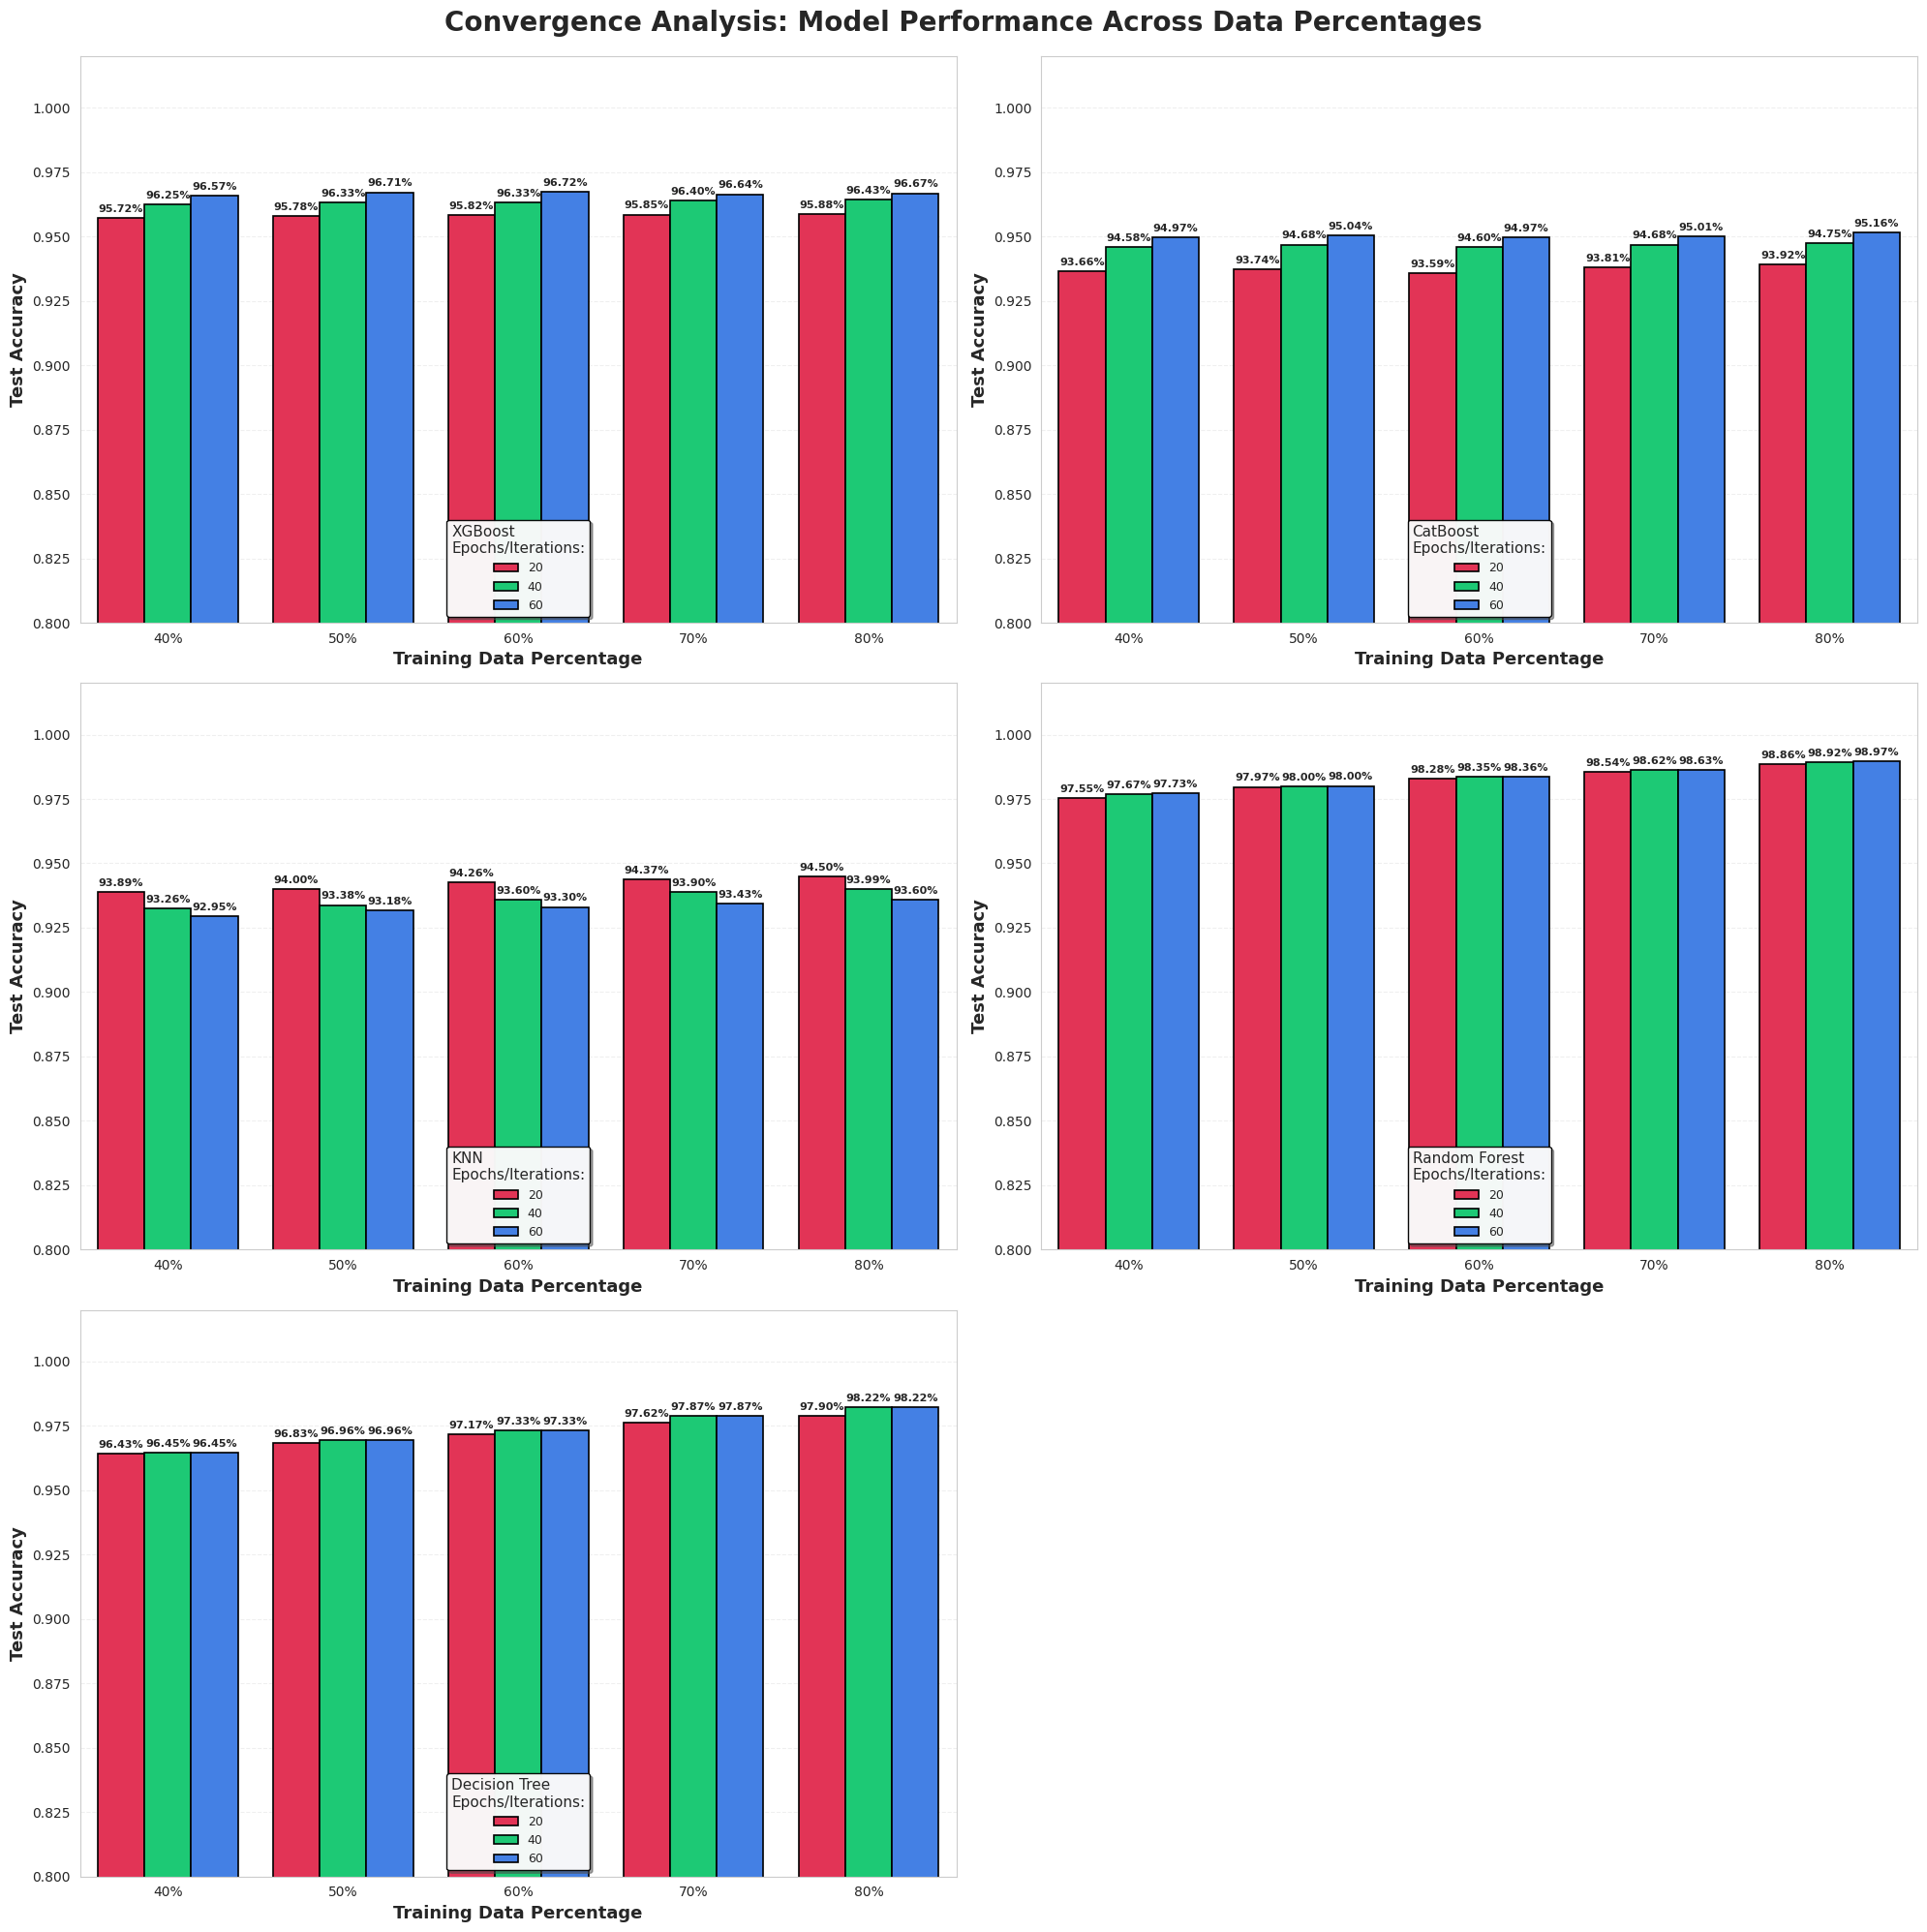

✓ Convergence analysis visualization saved!


In [ ]:
# Create grouped bar charts for convergence analysis
models = ['XGBoost', 'CatBoost', 'KNN', 'Random Forest', 'Decision Tree']

fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()

# High-contrast color palette for epochs
epoch_colors = ['#FF1744', '#00E676', '#2979FF']

for idx, model in enumerate(models):
    model_data = all_results[all_results['Model'] == model]

    ax = axes[idx]

    # Create barplot with custom colors
    sns.barplot(
        data=model_data,
        x='Data Partition',
        y='Accuracy',
        hue='Epochs',
        ax=ax,
        palette=epoch_colors,
        edgecolor='black',
        linewidth=1.2
    )

    # Remove top title
    ax.set_title("")

    ax.set_xlabel('Training Data Percentage', fontsize=13, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=13, fontweight='bold')
    ax.set_ylim([0.80, 1.02])

    # Add percentage labels on bars
    for container in ax.containers:
        labels = [f'{v.get_height():.2%}' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, fontsize=8, padding=3, fontweight='bold')

    # Legend inside each graph with model name
    ax.legend(
        title=f'{model}\nEpochs/Iterations:',
        title_fontsize=11,
        fontsize=9,
        loc='lower center',
        frameon=True,
        fancybox=True,
        shadow=True,
        edgecolor='black',
        facecolor='white',
        framealpha=0.95
    )

    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Enhance x-axis labels
    ax.tick_params(axis='both', labelsize=10)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Convergence Analysis: Model Performance Across Data Percentages',
             fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('convergence_analysis_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Convergence analysis visualization saved!")

### Model Comparison: Best Accuracy Across Data Partitions

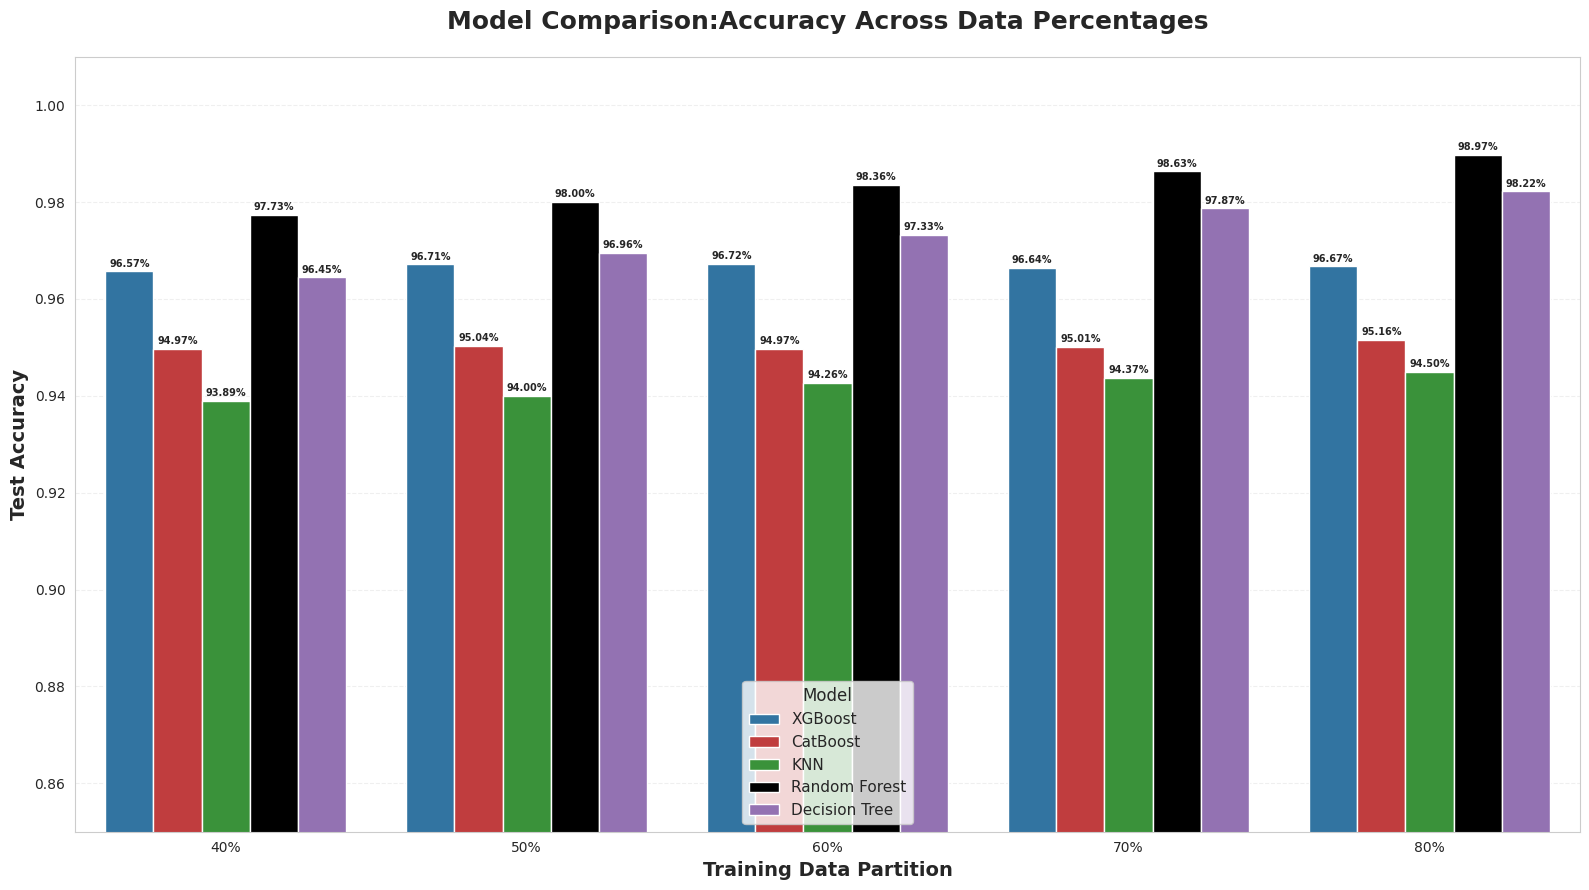

✓ Model comparison visualization saved!
✨ Highest accuracy: 0.9897 (98.97%) - Random Forest


In [ ]:
# Get best accuracy for each model at each partition
comparison_data = []

for model in models:
    model_data = all_results[all_results['Model'] == model]

    for partition in ['40%', '50%', '60%', '70%', '80%']:
        partition_data = model_data[model_data['Data Partition'] == partition]
        best_accuracy = partition_data['Accuracy'].max()

        comparison_data.append({
            'Model': model,
            'Data Partition': partition,
            'Accuracy': best_accuracy
        })

comparison_df = pd.DataFrame(comparison_data)

# Find the highest accuracy
max_accuracy = comparison_df['Accuracy'].max()

# Plot comparison
plt.figure(figsize=(16, 9))

# Create custom color palette - brightest color for best model
# Find which model has the highest accuracy
best_model = comparison_df[comparison_df['Accuracy'] == max_accuracy]['Model'].iloc[0]
models_list = comparison_df['Model'].unique()

# Create color mapping
colors = []
for model in models_list:
    if model == best_model:
        colors.append('#FF0054')  # for best model
    else:
        colors.append(None)  # Use default palette

# If only one model is, fill others with palette
palette = ['#1F77B4', '#D62728', '#2CA02C', '#9467BD', '#FF7F0E']
color_map = {}
palette_idx = 0
for i, model in enumerate(models_list):
    if model == best_model:
        color_map[model] = '#000000'  #
    else:
        color_map[model] = palette[palette_idx % len(palette)]
        palette_idx += 1

# Create the bar plot
ax = sns.barplot(
    data=comparison_df,
    x='Data Partition',
    y='Accuracy',
    hue='Model',
    palette=color_map
)

plt.title('Model Comparison:Accuracy Across Data Percentages',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Training Data Partition', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=14, fontweight='bold')
plt.legend(title='Model', title_fontsize=12, fontsize=11, loc='lower center')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim([0.85, 1.01])

# Add accurate percentage labels on bars
for container in ax.containers:
    labels = [f'{v.get_height():.2%}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, fontsize=7, padding=2, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_by_partition.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison visualization saved!")
print(f"✨ Highest accuracy: {max_accuracy:.4f} ({max_accuracy*100:.2f}%) - {best_model}")

### Identify Top 2 Models

In [ ]:
# Rank models by best accuracy
model_rankings = metrics_table.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("MODEL RANKINGS (By Accuracy on 80% Training Data)")
print("="*80 + "\n")
print(model_rankings.to_string(index=False))

# Get top 2 models
top_2 = model_rankings.head(2)
model1_name = top_2.iloc[0]['Model']
model2_name = top_2.iloc[1]['Model']

print(f"\n🏆 TOP 2 MODELS:")
print(f"   1st: {model1_name} - Accuracy: {top_2.iloc[0]['Accuracy']:.4f} ({top_2.iloc[0]['Accuracy']*100:.2f}%)")
print(f"   2nd: {model2_name} - Accuracy: {top_2.iloc[1]['Accuracy']:.4f} ({top_2.iloc[1]['Accuracy']*100:.2f}%)")
print("\nThese models will be combined to create a hybrid stacking ensemble.")


MODEL RANKINGS (By Accuracy on 80% Training Data)

        Model  Accuracy  F1-Score   Recall  Precision
Random Forest  0.989707  0.987354 0.988056   0.986653
Decision Tree  0.982228  0.978130 0.977249   0.979012
      XGBoost  0.966731  0.959032 0.957532   0.960536
     CatBoost  0.951581  0.940777 0.945682   0.935923
          KNN  0.944988  0.931863 0.925017   0.938811

🏆 TOP 2 MODELS:
   1st: Random Forest - Accuracy: 0.9897 (98.97%)
   2nd: Decision Tree - Accuracy: 0.9822 (98.22%)

These models will be combined to create a hybrid stacking ensemble.


### Create Hybrid Stacking Model (Top 2 Models)

In [ ]:
print("\n" + "="*80)
print("CREATING HYBRID STACKING MODEL")
print("="*80)
print(f"Combining: {model1_name} + {model2_name}")
print("Meta-learner: Logistic Regression\n")

# Get model instances for top 2
def get_best_model(model_name):
    """Return trained model instance"""
    if model_name == 'XGBoost':
        return xgb_final
    elif model_name == 'CatBoost':
        return cat_final
    elif model_name == 'KNN':
        return knn_final
    elif model_name == 'Random Forest':
        return rf_final
    elif model_name == 'Decision Tree':
        return dt_final

# Create fresh instances for stacking
def get_fresh_model(model_name):
    """Create new model instance for stacking"""
    if model_name == 'XGBoost':
        return XGBClassifier(n_estimators=60, random_state=42, eval_metric='logloss', use_label_encoder=False)
    elif model_name == 'CatBoost':
        return CatBoostClassifier(iterations=60, learning_rate=0.1, random_state=42, verbose=False)
    elif model_name == 'KNN':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=20)),
            ('knn', KNeighborsClassifier(n_neighbors=20))
        ])
    elif model_name == 'Random Forest':
        return RandomForestClassifier(n_estimators=60, random_state=42, n_jobs=-1)
    elif model_name == 'Decision Tree':
        return DecisionTreeClassifier(max_depth=60, random_state=42)

# Create stacking classifier
stacking_model = StackingClassifier(
    estimators=[
        (model1_name.replace(' ', '_').lower(), get_fresh_model(model1_name)),
        (model2_name.replace(' ', '_').lower(), get_fresh_model(model2_name))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)

print("Training Hybrid Stacking Model...")
print("(This uses 5-fold cross-validation, may take a moment...)")
stacking_model.fit(X_train, y_train)

# Predictions
y_pred_hybrid = stacking_model.predict(X_test)
y_train_pred_hybrid = stacking_model.predict(X_train)

# Calculate metrics
hybrid_metrics = {
    'Model': 'Hybrid Stacking',
    'Accuracy': metrics.accuracy_score(y_test, y_pred_hybrid),
    'F1-Score': metrics.f1_score(y_test, y_pred_hybrid),
    'Recall': metrics.recall_score(y_test, y_pred_hybrid),
    'Precision': metrics.precision_score(y_test, y_pred_hybrid)
}

print(f"\n✓ Hybrid Stacking Model Results:")
print(f"   Accuracy:  {hybrid_metrics['Accuracy']:.4f} ({hybrid_metrics['Accuracy']*100:.2f}%)")
print(f"   F1-Score:  {hybrid_metrics['F1-Score']:.4f}")
print(f"   Recall:    {hybrid_metrics['Recall']:.4f}")
print(f"   Precision: {hybrid_metrics['Precision']:.4f}")

print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred_hybrid))


CREATING HYBRID STACKING MODEL
Combining: Random Forest + Decision Tree
Meta-learner: Logistic Regression

Training Hybrid Stacking Model...
(This uses 5-fold cross-validation, may take a moment...)

✓ Hybrid Stacking Model Results:
   Accuracy:  0.9900 (99.00%)
   F1-Score:  0.9877
   Recall:    0.9883
   Precision: 0.9871

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15391
           1       0.99      0.99      0.99     10549

    accuracy                           0.99     25940
   macro avg       0.99      0.99      0.99     25940
weighted avg       0.99      0.99      0.99     25940



### Add Hybrid Model to Convergence Analysis

In [ ]:
# Train hybrid model on different data partitions for convergence analysis
print("\n" + "="*70)
print("HYBRID MODEL - Convergence Analysis")
print("="*70 + "\n")

hybrid_results = []

for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    print(f"Training with {int(fraction*100)}% data ({len(X_train_frac)} samples):")

    # Only test with one epoch value for hybrid (60) since it's computationally expensive
    for epoch_val in [60]:  # Just using best epoch
        model = StackingClassifier(
            estimators=[
                (model1_name.replace(' ', '_').lower(), get_fresh_model(model1_name)),
                (model2_name.replace(' ', '_').lower(), get_fresh_model(model2_name))
            ],
            final_estimator=LogisticRegression(max_iter=1000, random_state=42),
            cv=5  # Reduced CV for speed
        )

        accuracy = train_and_evaluate(model, X_train_frac, y_train_frac, X_test, y_test)

        # Add results for all epoch values for consistency in plotting
        for epochs in EPOCHS:
            hybrid_results.append({
                'Model': 'Hybrid Stacking',
                'Data Partition': f"{int(fraction*100)}%",
                'Epochs': epochs,
                'Accuracy': accuracy  # Same accuracy for all epochs
            })

        print(f"  Stacking Model → Accuracy: {accuracy:.4f}")

hybrid_df = pd.DataFrame(hybrid_results)
print("\n✓ Hybrid model convergence analysis completed!")


HYBRID MODEL - Convergence Analysis

Training with 40% data (51879 samples):
  Stacking Model → Accuracy: 0.9779
Training with 50% data (64848 samples):
  Stacking Model → Accuracy: 0.9802
Training with 60% data (77818 samples):
  Stacking Model → Accuracy: 0.9837
Training with 70% data (90788 samples):
  Stacking Model → Accuracy: 0.9867
Training with 80% data (103758 samples):
  Stacking Model → Accuracy: 0.9900

✓ Hybrid model convergence analysis completed!


### Updated Comparison with Hybrid Model

In [ ]:
# IMPORTANT: Add hybrid_df to all_results first!
all_results_with_hybrid = pd.concat([
    all_results,  # Original 5 models
    hybrid_df     # Add hybrid convergence data
], ignore_index=True)

# Now add hybrid model to comparison data
comparison_data = []

for partition in ['40%', '50%', '60%', '70%', '80%']:
    partition_data = hybrid_df[hybrid_df['Data Partition'] == partition]
    best_accuracy = partition_data['Accuracy'].max()

    comparison_data.append({
        'Model': 'Hybrid Stacking',
        'Data Partition': partition,
        'Accuracy': best_accuracy
    })

print(f"\n✓ Hybrid model added to comparison data")
print(f"✓ all_results_with_hybrid now has {len(all_results_with_hybrid)} rows")


✓ Hybrid model added to comparison data
✓ all_results_with_hybrid now has 90 rows


In [ ]:
# Update all_results to include Hybrid Stacking convergence data
all_results_with_hybrid = pd.concat([
    xgb_df,
    cat_df,
    knn_df,
    rf_df,
    dt_df,
    hybrid_df  # ← ADD THIS!
], ignore_index=True)

print("\n✓ Combined all results including Hybrid Stacking")
print(f"Total rows: {len(all_results_with_hybrid)}")
print(f"Models: {all_results_with_hybrid['Model'].unique()}")


✓ Combined all results including Hybrid Stacking
Total rows: 90
Models: ['XGBoost' 'CatBoost' 'KNN' 'Random Forest' 'Decision Tree'
 'Hybrid Stacking']


## 7. Conclusion

### Final Comparison: All Models Including Hybrid

In [ ]:
# Create final metrics table with hybrid
final_metrics_table = pd.DataFrame([
    xgb_metrics, cat_metrics, knn_metrics, rf_metrics, dt_metrics, hybrid_metrics
])

# Sort by accuracy
final_metrics_table = final_metrics_table.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON (Including Hybrid Stacking Model)")
print("="*80 + "\n")
print(final_metrics_table.to_string(index=False))
print("\n" + "="*80)

# Save final table
final_metrics_table.to_csv('final_model_comparison_with_hybrid.csv', index=False)
print("\n✓ Final comparison saved to 'final_model_comparison_with_hybrid.csv'")


FINAL MODEL COMPARISON (Including Hybrid Stacking Model)

          Model  Accuracy  F1-Score   Recall  Precision
Hybrid Stacking  0.990015  0.987732 0.988340   0.987124
  Random Forest  0.989707  0.987354 0.988056   0.986653
  Decision Tree  0.982228  0.978130 0.977249   0.979012
        XGBoost  0.966731  0.959032 0.957532   0.960536
       CatBoost  0.951581  0.940777 0.945682   0.935923
            KNN  0.944988  0.931863 0.925017   0.938811


✓ Final comparison saved to 'final_model_comparison_with_hybrid.csv'


### Final Bar Graph: All Models Including Hybrid

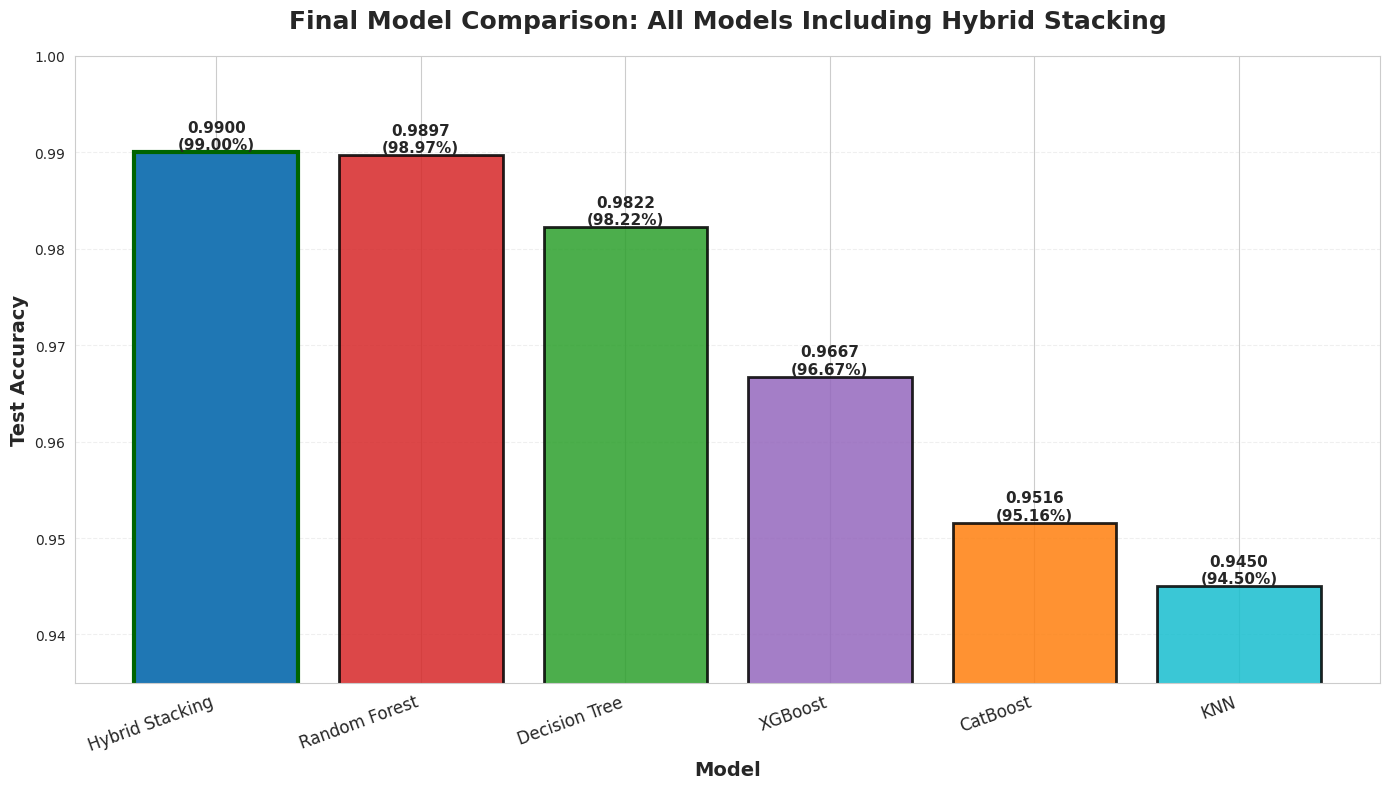

✓ Final comparison bar graph saved!


In [ ]:
# Create comprehensive bar chart comparing all models including hybrid
plt.figure(figsize=(14, 8))

# Define colors for each model
colors = ['#1F77B4', '#D62728', '#2CA02C', '#9467BD', '#FF7F0E', '#17BECF']

models_list = final_metrics_table['Model'].values
accuracies = final_metrics_table['Accuracy'].values

bars = plt.bar(models_list, accuracies, color=colors,
               edgecolor='black', linewidth=2, alpha=0.85)

# Highlight hybrid model
for i, (bar, model) in enumerate(zip(bars, models_list)):
    if model == 'Hybrid Stacking':
        bar.set_linewidth(3)
        bar.set_edgecolor('darkgreen')
        bar.set_alpha(1.0)

plt.title('Final Model Comparison: All Models Including Hybrid Stacking',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=14, fontweight='bold')
plt.ylim([min(accuracies) - 0.01, max(accuracies) + 0.01])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    label = f'{acc:.4f}\n({acc*100:.2f}%)'
    plt.text(bar.get_x() + bar.get_width()/2., height,
            label, ha='center', va='bottom',
            fontweight='bold', fontsize=11)

plt.xticks(rotation=20, ha='right', fontsize=12)
plt.tight_layout()
plt.savefig('final_comparison_all_models_with_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Final comparison bar graph saved!")

### Final Bar Graph: Models Across All Data Partitions (Including Hybrid)

✨ Best model: Hybrid Stacking with 0.9900 (99.00%)


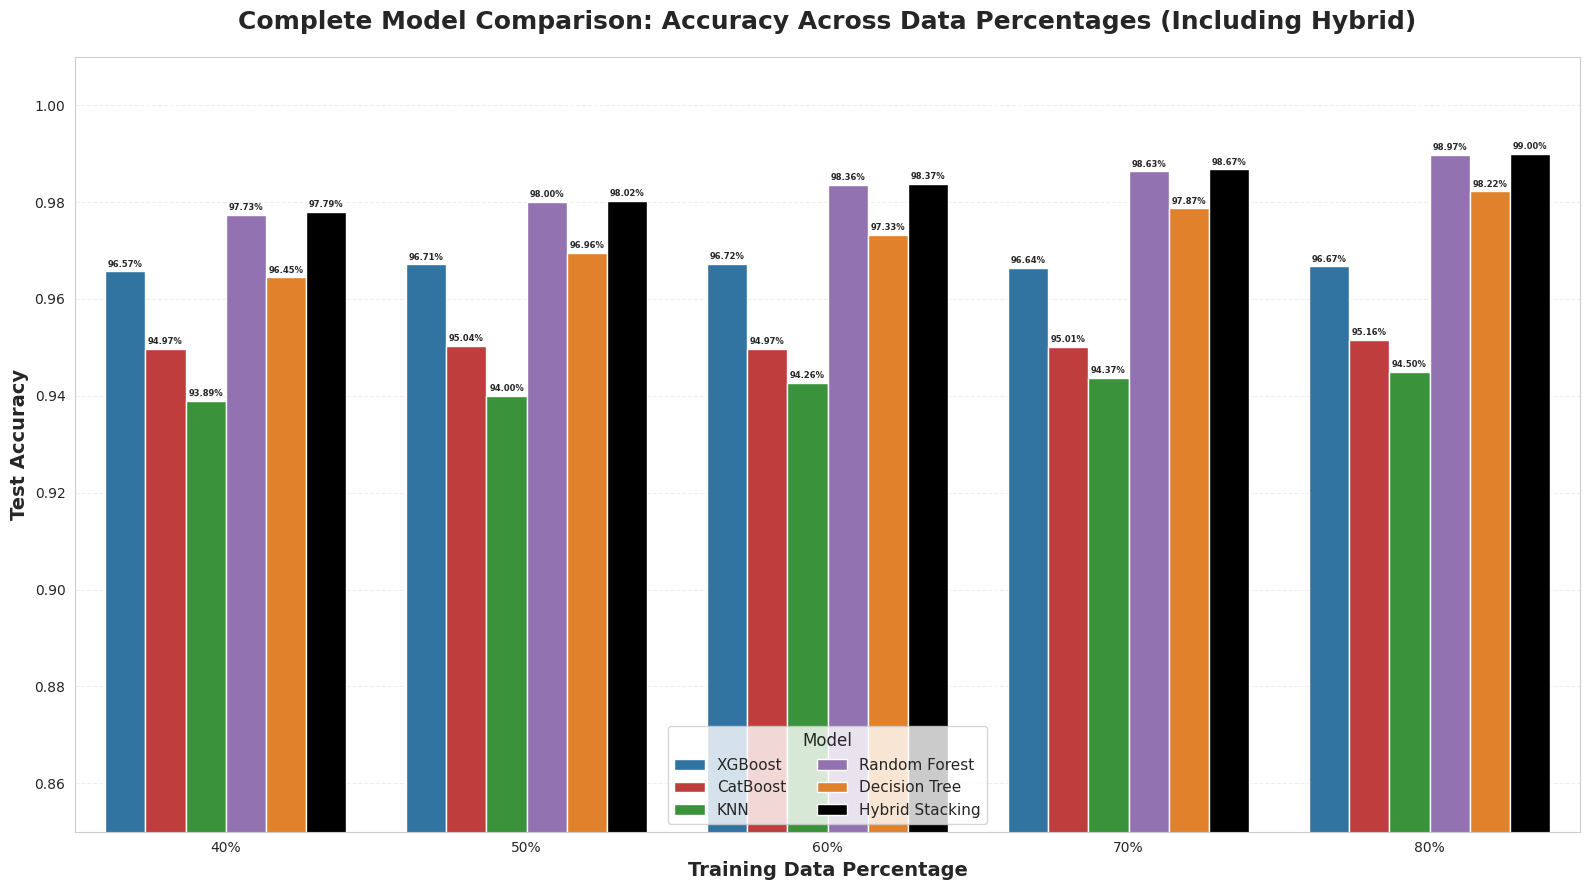

✓ Complete comparison across partitions saved!
✨ Highest accuracy: 0.9900 (99.00%) - Hybrid Stacking


In [ ]:
# Get best accuracy for each model at each partition
comparison_data = []

MODEL_ORDER = ['XGBoost', 'CatBoost', 'KNN', 'Random Forest', 'Decision Tree', 'Hybrid Stacking']

for model in MODEL_ORDER:
     model_data = all_results_with_hybrid[all_results_with_hybrid['Model'] == model]
     for partition in ['40%', '50%', '60%', '70%', '80%']:
        partition_data = model_data[model_data['Data Partition'] == partition]
        best_accuracy = partition_data['Accuracy'].max()

        comparison_data.append({
            'Model': model,
            'Data Partition': partition,
            'Accuracy': best_accuracy
        })

comparison_df_with_hybrid = pd.DataFrame(comparison_data)

# Find the best model
max_accuracy = comparison_df_with_hybrid['Accuracy'].max()
best_model = comparison_df_with_hybrid[comparison_df_with_hybrid['Accuracy'] == max_accuracy]['Model'].iloc[0]

print(f"✨ Best model: {best_model} with {max_accuracy:.4f} ({max_accuracy*100:.2f}%)")

# Build color map - gold for best model, palette for others
palette = ['#1F77B4', '#D62728', '#2CA02C', '#9467BD', '#FF7F0E', '#17BECF']
color_map = {}
palette_idx = 0
for model in MODEL_ORDER:
    if model == best_model:
        color_map[model] = '#000000'  # Gold for best model
    else:
        color_map[model] = palette[palette_idx % len(palette)]
        palette_idx += 1

# Plot
plt.figure(figsize=(16, 9))

ax = sns.barplot(
    data=comparison_df_with_hybrid,
    x='Data Partition',
    y='Accuracy',
    hue='Model',
    hue_order=MODEL_ORDER,
    palette=color_map
)

plt.title('Complete Model Comparison: Accuracy Across Data Percentages (Including Hybrid)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Training Data Percentage', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=14, fontweight='bold')
plt.legend(title='Model', title_fontsize=12, fontsize=11, loc='lower center', ncol=2)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim([0.85, 1.01])

# Add percentage labels on bars
for container in ax.containers:
    labels = [f'{v.get_height():.2%}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, fontsize=6, padding=2, fontweight='bold')

plt.tight_layout()
plt.savefig('complete_model_comparison_all_partitions_with_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Complete comparison across partitions saved!")
print(f"✨ Highest accuracy: {max_accuracy:.4f} ({max_accuracy*100:.2f}%) - {best_model}")

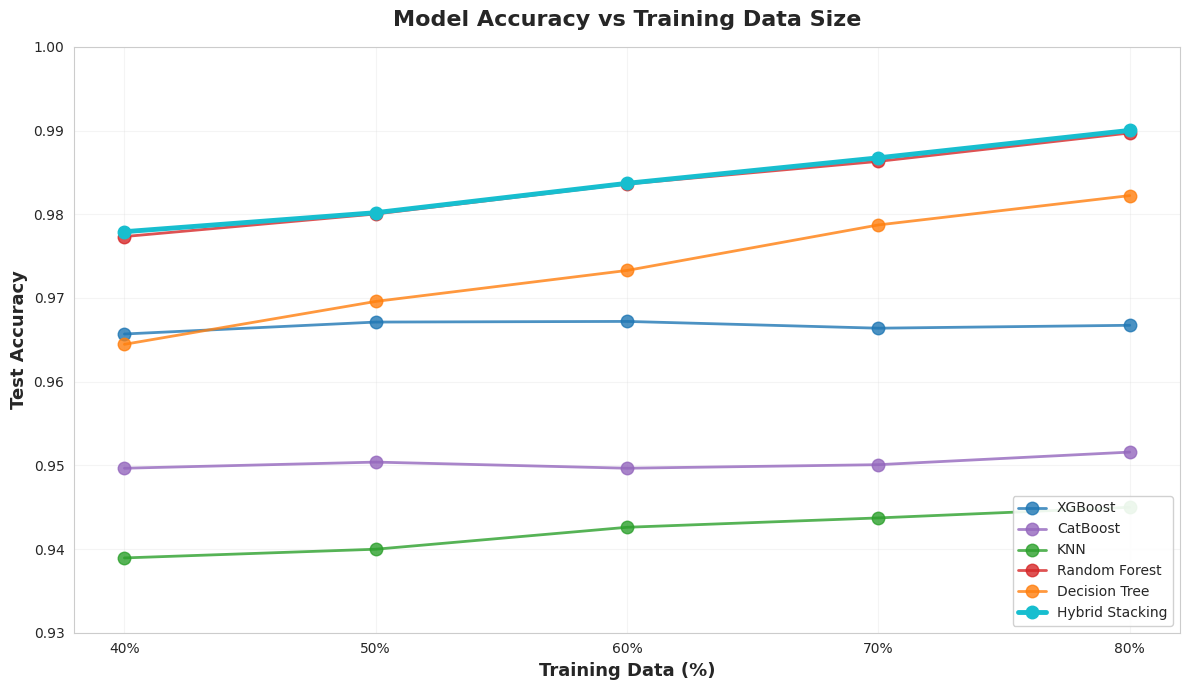

✓ Clean line plot saved!


In [ ]:
# Clean Line Plot - Publication Ready
plt.figure(figsize=(12, 7))

MODEL_ORDER = ['XGBoost', 'CatBoost', 'KNN', 'Random Forest', 'Decision Tree', 'Hybrid Stacking']

# Professional color palette
colors = ['#1F77B4', '#9467BD', '#2CA02C', '#D62728' , '#FF7F0E', '#17BECF']

partitions_numeric = [40, 50, 60, 70, 80]

for idx, model in enumerate(MODEL_ORDER):
    accuracies = []
    for partition in ['40%', '50%', '60%', '70%', '80%']:
        model_partition_data = comparison_df_with_hybrid[
            (comparison_df_with_hybrid['Model'] == model) &
            (comparison_df_with_hybrid['Data Partition'] == partition)
        ]
        if not model_partition_data.empty:
            accuracies.append(model_partition_data['Accuracy'].values[0])

    linewidth = 3.5 if model == 'Hybrid Stacking' else 2
    alpha = 1.0 if model == 'Hybrid Stacking' else 0.8

    plt.plot(
        partitions_numeric,
        accuracies,
        label=model,
        color=colors[idx],
        linewidth=linewidth,
        marker='o',
        markersize=9,
        alpha=alpha
    )

plt.title('Model Accuracy vs Training Data Size',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Data (%)', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=13, fontweight='bold')
plt.xticks(partitions_numeric, ['40%', '50%', '60%', '70%', '80%'])
plt.ylim([0.93, 1.0])
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('models_accuracy_lineplot_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Clean line plot saved!")

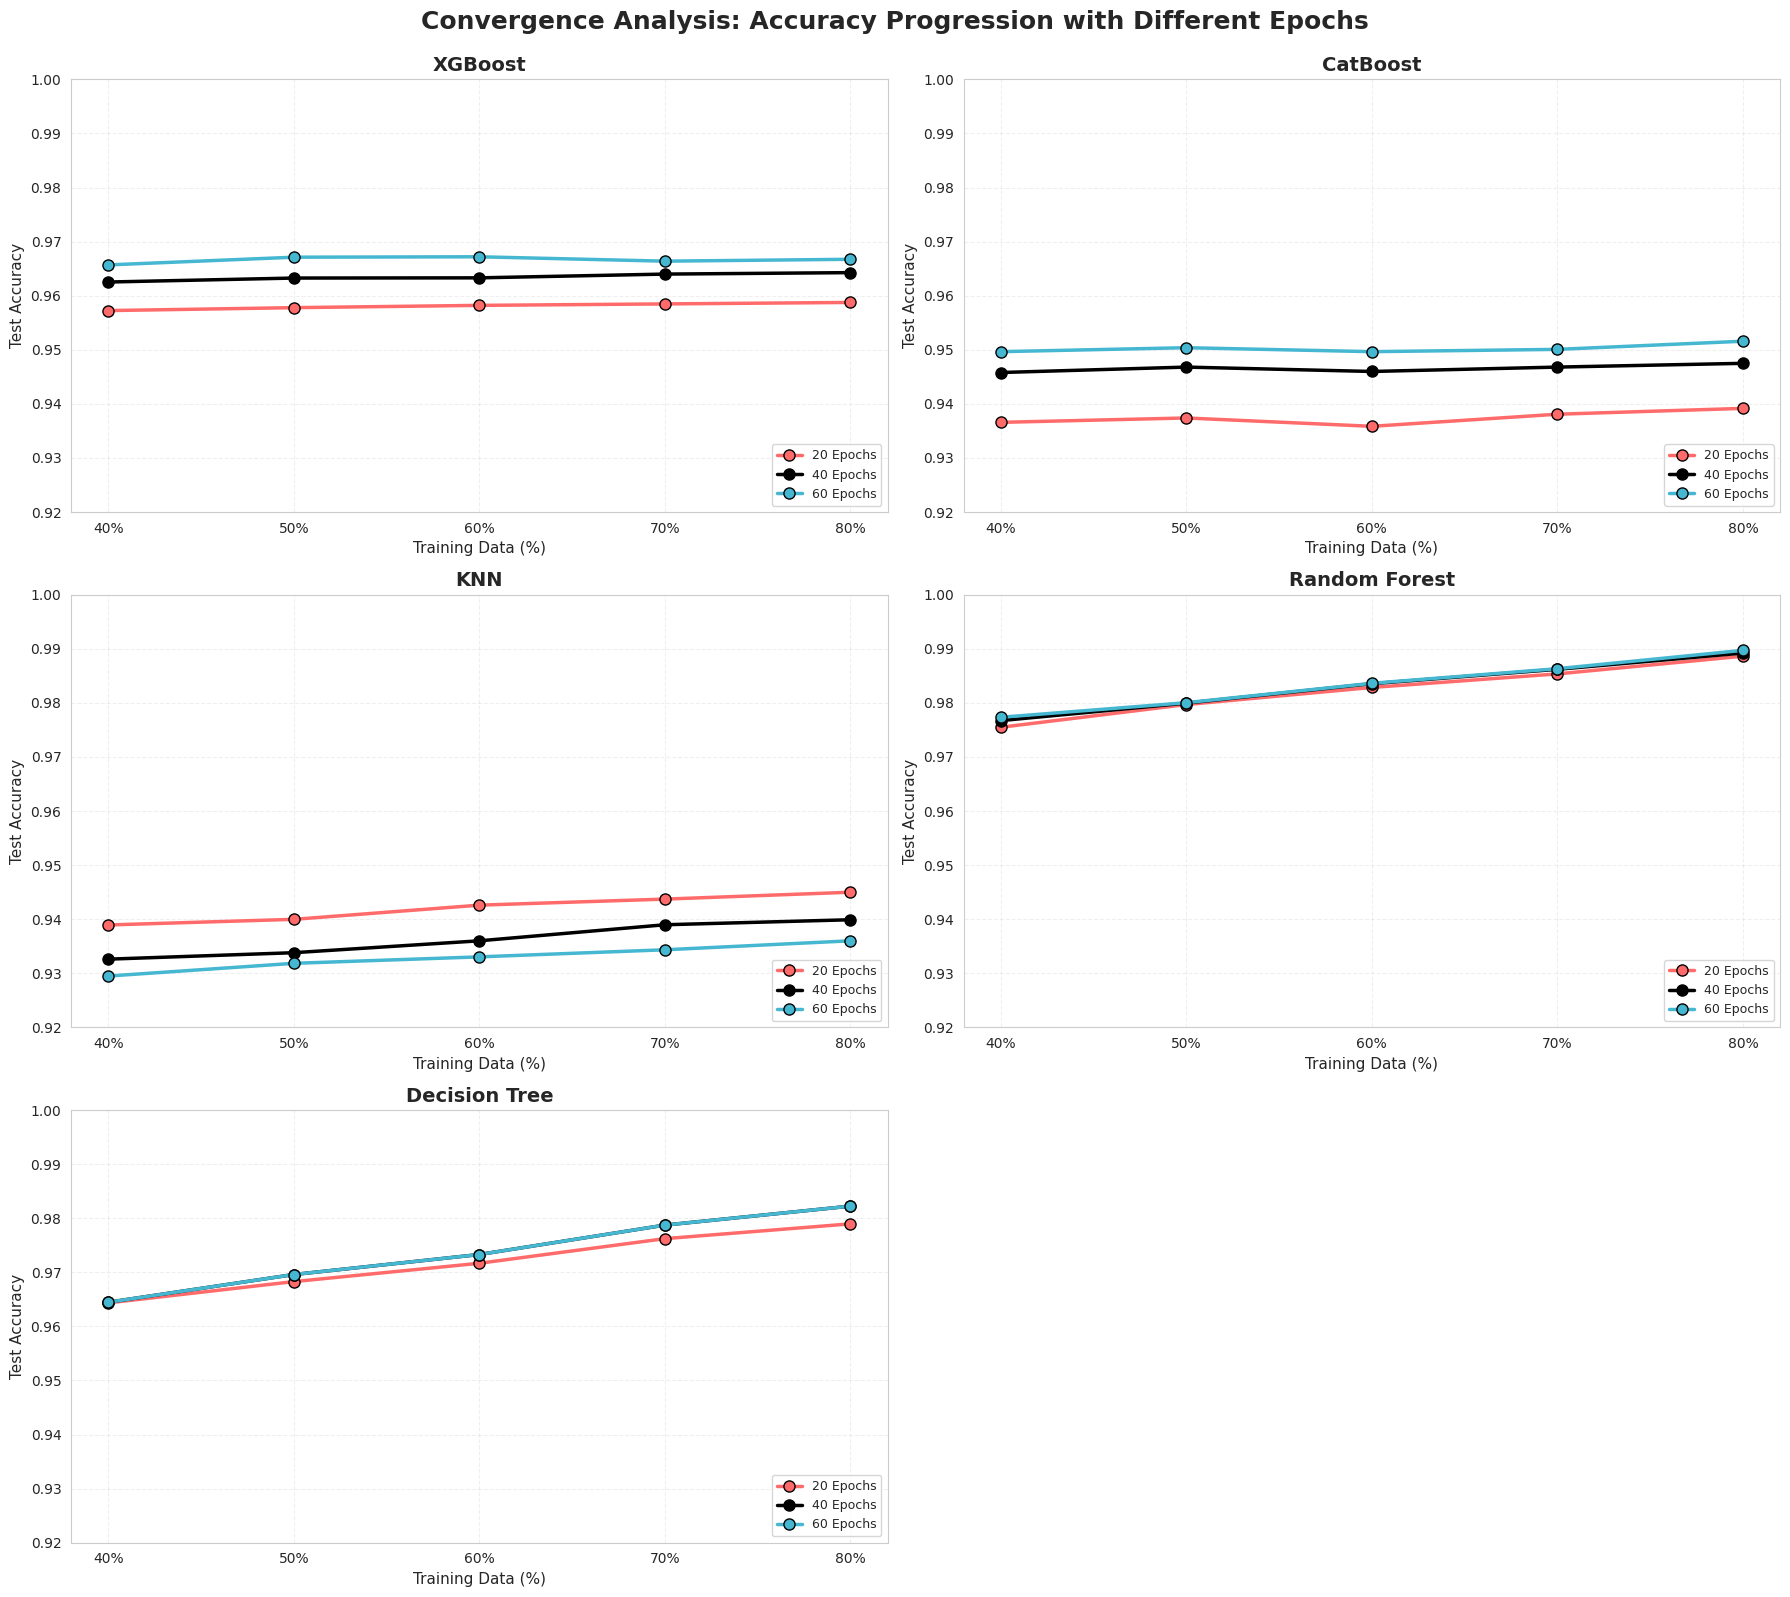

✓ Line plot with epochs saved!


In [ ]:
# Line Plots: Each Model with Different Epochs
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

MODEL_ORDER = ['XGBoost', 'CatBoost', 'KNN', 'Random Forest', 'Decision Tree', 'Hybrid Stacking']

# Colors for epochs
epoch_colors = {20: '#FF6B6B', 40: '#000000', 60: '#45B7D1'}

partitions_numeric = [40, 50, 60, 70, 80]

for idx, model in enumerate(MODEL_ORDER):
    ax = axes[idx]

    # Plot each epoch separately
    for epoch in EPOCHS:
        accuracies = []
        for partition in ['40%', '50%', '60%', '70%', '80%']:
            model_data = all_results_with_hybrid[
                (all_results_with_hybrid['Model'] == model) &
                (all_results_with_hybrid['Data Partition'] == partition) &
                (all_results_with_hybrid['Epochs'] == epoch)
            ]
            if not model_data.empty:
                accuracies.append(model_data['Accuracy'].values[0])
            else:
                accuracies.append(None)

        ax.plot(
            partitions_numeric,
            accuracies,
            label=f'{epoch} Epochs',
            color=epoch_colors[epoch],
            linewidth=2.5,
            marker='o',
            markersize=8,
            markeredgecolor='black',
            markeredgewidth=1
        )

    # Formatting
    ax.set_title(f'{model}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Training Data (%)', fontsize=11)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    ax.set_xticks(partitions_numeric)
    ax.set_xticklabels(['40%', '50%', '60%', '70%', '80%'])
    ax.set_ylim([0.92, 1.0])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='lower right')

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Convergence Analysis: Accuracy Progression with Different Epochs',
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('all_models_line_plot_with_epochs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Line plot with epochs saved!")

### Summary and Recommendations

In [ ]:
# COLLECT COMPREHENSIVE METRICS - All Models, All Partitions, All Metrics
print("\n" + "="*80)
print("COLLECTING COMPREHENSIVE METRICS")
print("="*80)
print("Training models on all partitions to collect Accuracy, Precision, Recall, F1-Score")
print("This will take a few minutes...\n")

MODEL_ORDER = ['XGBoost', 'CatBoost', 'KNN', 'Random Forest', 'Decision Tree', 'Hybrid Stacking (RF+DT)']
comprehensive_metrics = []

def collect_metrics(y_true, y_pred, model_name, partition, param_value):
    """Collect all 4 metrics"""
    return {
        'Model': model_name,
        'Data Partition': partition,
        'Parameter': param_value,   # renamed from Epochs (more correct)
        'Accuracy': metrics.accuracy_score(y_true, y_pred),
        'Precision': metrics.precision_score(y_true, y_pred),
        'Recall': metrics.recall_score(y_true, y_pred),
        'F1-Score': metrics.f1_score(y_true, y_pred)
    }

# Train each model on each partition
for fraction in DATA_FRACTIONS:
    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    partition_label = f"{int(fraction*100)}%"

    print(f"\n{'='*70}")
    print(f"Processing {partition_label} partition ({len(X_train_frac)} samples)")
    print('='*70)

    # XGBoost
    print("  XGBoost...", end="")
    for n_est in EPOCHS:
        model = XGBClassifier(
            n_estimators=n_est,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )
        model.fit(X_train_frac, y_train_frac)
        y_pred = model.predict(X_test)
        comprehensive_metrics.append(
            collect_metrics(y_test, y_pred, 'XGBoost', partition_label, n_est)
        )
    print(" ✓")

    # CatBoost
    print("  CatBoost...", end="")
    for n_iter in EPOCHS:
        model = CatBoostClassifier(
            iterations=n_iter,
            learning_rate=0.1,
            random_state=42,
            verbose=False
        )
        model.fit(X_train_frac, y_train_frac)
        y_pred = model.predict(X_test)
        comprehensive_metrics.append(
            collect_metrics(y_test, y_pred, 'CatBoost', partition_label, n_iter)
        )
    print(" ✓")

    # KNN
    print("  KNN...", end="")
    for n_neighbors in EPOCHS:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=20)),
            ('knn', KNeighborsClassifier(n_neighbors=n_neighbors))
        ])
        model.fit(X_train_frac, y_train_frac)
        y_pred = model.predict(X_test)
        comprehensive_metrics.append(
            collect_metrics(y_test, y_pred, 'KNN', partition_label, n_neighbors)
        )
    print(" ✓")

    # Random Forest
    print("  Random Forest...", end="")
    for n_trees in EPOCHS:
        model = RandomForestClassifier(
            n_estimators=n_trees,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_frac, y_train_frac)
        y_pred = model.predict(X_test)
        comprehensive_metrics.append(
            collect_metrics(y_test, y_pred, 'Random Forest', partition_label, n_trees)
        )
    print(" ✓")

    # Decision Tree
    print("  Decision Tree...", end="")
    for max_depth in EPOCHS:
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=42
        )
        model.fit(X_train_frac, y_train_frac)
        y_pred = model.predict(X_test)
        comprehensive_metrics.append(
            collect_metrics(y_test, y_pred, 'Decision Tree', partition_label, max_depth)
        )
    print(" ✓")

    # ✅ Hybrid Stacking (RF + DT) — TRAIN ONCE (NO EPOCH LOOP)
    print("  Hybrid Stacking...", end="")

    hybrid_model = StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('dt', DecisionTreeClassifier(max_depth=None, random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=3
    )

    hybrid_model.fit(X_train_frac, y_train_frac)
    y_pred = hybrid_model.predict(X_test)

    comprehensive_metrics.append(
        collect_metrics(y_test, y_pred, 'Hybrid Stacking (RF+DT)', partition_label, 100)
    )

    print(" ✓")

# Create DataFrame
comprehensive_df = pd.DataFrame(comprehensive_metrics)

print("\n" + "="*80)
print("✓ COLLECTION COMPLETE!")
print("="*80)
print(f"\nTotal data points: {len(comprehensive_df)}")
print(f"Models: {len(comprehensive_df['Model'].unique())}")
print(f"Partitions: {len(comprehensive_df['Data Partition'].unique())}")
print("\nNote: Hybrid model trained once per partition (no epochs).")

# Save
comprehensive_df.to_csv('comprehensive_all_metrics_all_partitions.csv', index=False)
print("\n✓ Saved to 'comprehensive_all_metrics_all_partitions.csv'")

# Show sample
print("\n📊 Sample Data:")
print(comprehensive_df.head(10).to_string(index=False))



COLLECTING COMPREHENSIVE METRICS
Training models on all partitions to collect Accuracy, Precision, Recall, F1-Score
This will take a few minutes...


Processing 40% partition (51879 samples)
  XGBoost... ✓
  CatBoost... ✓
  KNN... ✓
  Random Forest... ✓
  Decision Tree... ✓
  Hybrid Stacking... ✓

Processing 50% partition (64848 samples)
  XGBoost... ✓
  CatBoost... ✓
  KNN... ✓
  Random Forest... ✓
  Decision Tree... ✓
  Hybrid Stacking... ✓

Processing 60% partition (77818 samples)
  XGBoost... ✓
  CatBoost... ✓
  KNN... ✓
  Random Forest... ✓
  Decision Tree... ✓
  Hybrid Stacking... ✓

Processing 70% partition (90788 samples)
  XGBoost... ✓
  CatBoost... ✓
  KNN... ✓
  Random Forest... ✓
  Decision Tree... ✓
  Hybrid Stacking... ✓

Processing 80% partition (103758 samples)
  XGBoost... ✓
  CatBoost... ✓
  KNN... ✓
  Random Forest... ✓
  Decision Tree... ✓
  Hybrid Stacking... ✓

✓ COLLECTION COMPLETE!

Total data points: 80
Models: 6
Partitions: 5

Note: Hybrid model trained once 

In [ ]:
# DISPLAY: All Metrics for All Models on All Partitions
print("\n" + "="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80 + "\n")

# For each partition, get best parameter for each model
for partition in ['40%', '50%', '60%', '70%', '80%']:
    print(f"\n{'='*80}")
    print(f"{partition} TRAINING DATA")
    print('='*80)

    partition_data = comprehensive_df[comprehensive_df['Data Partition'] == partition]

    # Get best accuracy for each model
    summary_rows = []
    for model in MODEL_ORDER:
        model_data = partition_data[partition_data['Model'] == model]

        # Row with highest accuracy
        best_row = model_data.loc[model_data['Accuracy'].idxmax()]

        summary_rows.append({
            'Model': model,
            'Best Parameter': int(best_row['Parameter']),   # ✅ changed
            'Accuracy': best_row['Accuracy'],
            'Precision': best_row['Precision'],
            'Recall': best_row['Recall'],
            'F1-Score': best_row['F1-Score']
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.sort_values('Accuracy', ascending=False)

    print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("Note: Hybrid model is trained once per partition (no epoch-based training).")
print("="*80)



COMPREHENSIVE METRICS SUMMARY


40% TRAINING DATA
                  Model  Best Parameter  Accuracy  Precision   Recall  F1-Score
Hybrid Stacking (RF+DT)             100  0.977988   0.972175 0.973742  0.972958
          Random Forest              60  0.977332   0.972220 0.972035  0.972127
                XGBoost              60  0.965690   0.957469 0.958195  0.957832
          Decision Tree              40  0.964456   0.957079 0.955446  0.956262
               CatBoost              60  0.949653   0.935621 0.940942  0.938274
                    KNN              20  0.938936   0.927842 0.921509  0.924665

50% TRAINING DATA
                  Model  Best Parameter  Accuracy  Precision   Recall  F1-Score
          Random Forest              60  0.980031   0.975989 0.974879  0.975434
Hybrid Stacking (RF+DT)             100  0.979915   0.976525 0.974026  0.975274
          Decision Tree              40  0.969584   0.963790 0.961323  0.962555
                XGBoost              60  0.967116 


CREATING IEEE-FORMAT METRIC COMPARISON PLOTS (ALL MODELS)


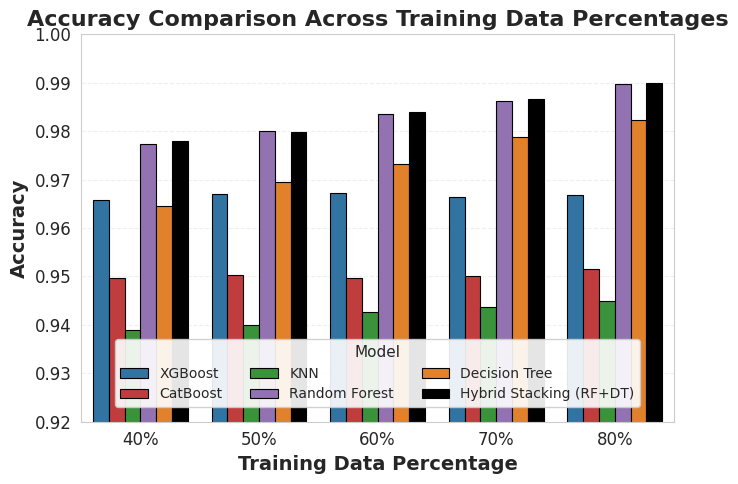

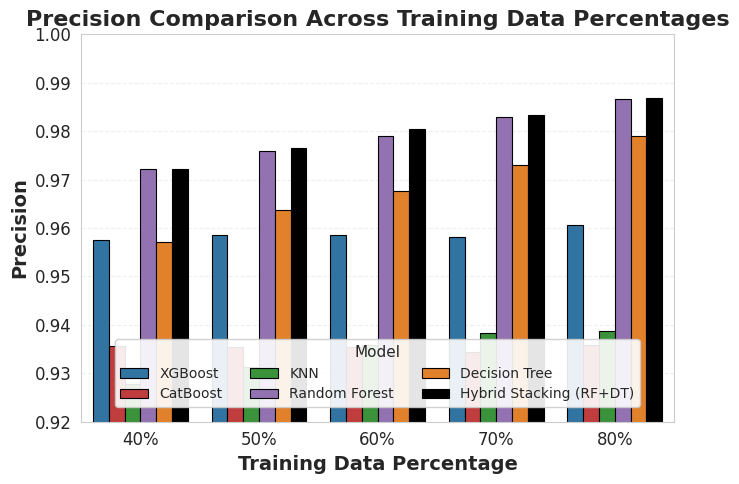

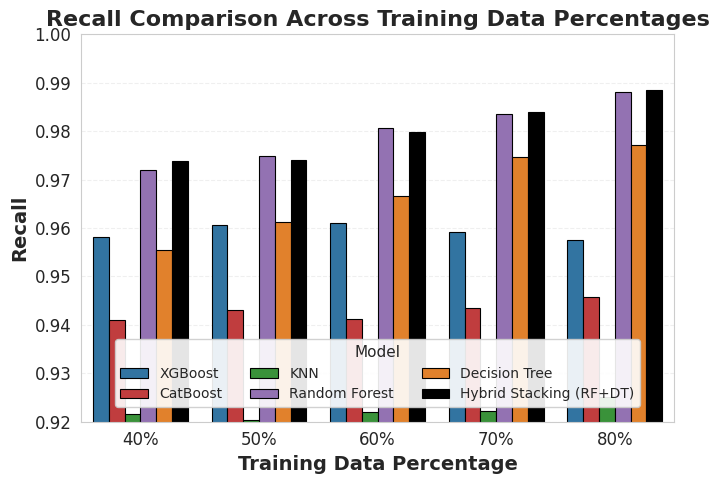

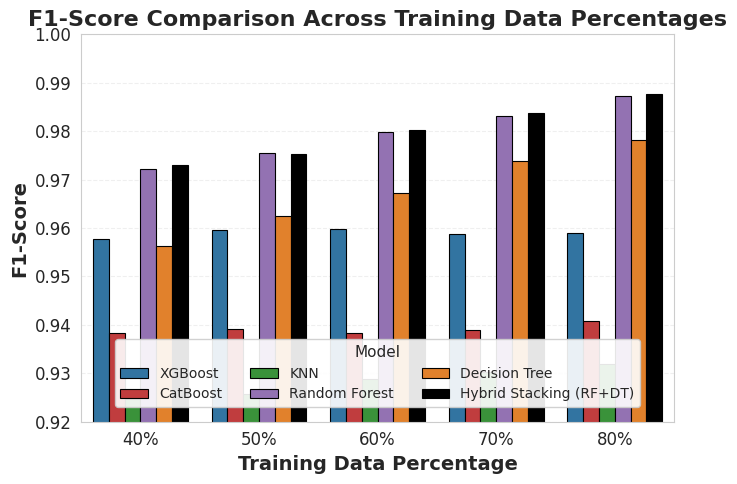

✓ IEEE-optimized separate metric plots generated successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("CREATING IEEE-FORMAT METRIC COMPARISON PLOTS (ALL MODELS)")
print("="*80)

# ===============================
# IEEE GLOBAL FONT SETTINGS
# ===============================
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'legend.title_fontsize': 12
})

best_metrics_data = []

for partition in ['40%', '50%', '60%', '70%', '80%']:
    partition_data = comprehensive_df[
        comprehensive_df['Data Partition'] == partition
    ]

    for model in MODEL_ORDER:
        model_data = partition_data[
            partition_data['Model'] == model
        ]

        best_row = model_data.loc[
            model_data['Accuracy'].idxmax()
        ]

        best_metrics_data.append({
            'Model': model,
            'Data Partition': partition,
            'Accuracy': best_row['Accuracy'],
            'Precision': best_row['Precision'],
            'Recall': best_row['Recall'],
            'F1-Score': best_row['F1-Score']
        })

best_metrics_df = pd.DataFrame(best_metrics_data)

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

color_map = {
    'XGBoost': '#1F77B4',
    'CatBoost': '#D62728',
    'KNN': '#2CA02C',
    'Random Forest': '#9467BD',
    'Decision Tree': '#FF7F0E',
    'Hybrid Stacking (RF+DT)': '#000000'
}

for metric in metrics_list:

    # IEEE 2-column width friendly
    plt.figure(figsize=(7, 5))

    ax = sns.barplot(
        data=best_metrics_df,
        x='Data Partition',
        y=metric,
        hue='Model',
        hue_order=MODEL_ORDER,
        palette=color_map,
        edgecolor='black',
        linewidth=0.8
    )

    ax.set_title(
        f'{metric} Comparison Across Training Data Percentages',
        fontweight='bold'
    )

    ax.set_xlabel('Training Data Percentage', fontweight='bold')
    ax.set_ylabel(metric, fontweight='bold')

    ax.set_ylim([0.92, 1.00])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Improve tick visibility
    ax.tick_params(axis='both', which='major', width=1.2)

    # Legend inside bottom center
    ax.legend(
    title='Model',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
    framealpha=0.9,
    fontsize=10,           # ↓ smaller text
    title_fontsize=11     # ↓ smaller title
)

    plt.tight_layout()
    plt.savefig(
        f'{metric.lower()}_all_models_IEEE.png',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()

print("✓ IEEE-optimized separate metric plots generated successfully!")

In [ ]:
print("\n" + "="*80)
print("TRAINING NEW HYBRID MODEL (20, 40, 60 TREES)")
print("="*80)

import pandas as pd
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# New results container (separate from old)
hybrid_new_results = []

RF_TREES = [20, 40, 60]
DATA_FRACTIONS = [0.4, 0.5, 0.6, 0.7, 0.8]

for fraction in DATA_FRACTIONS:

    X_train_frac, y_train_frac = get_data_fraction(X_train, y_train, fraction)
    partition_label = f"{int(fraction*100)}%"

    print(f"\nTraining Hybrid on {partition_label} data...")

    for n_trees in RF_TREES:

        hybrid_model = StackingClassifier(
            estimators=[
                ('rf', RandomForestClassifier(
                    n_estimators=n_trees,
                    random_state=42,
                    n_jobs=-1
                )),
                ('dt', DecisionTreeClassifier(
                    max_depth=8,
                    random_state=42
                ))
            ],
            final_estimator=LogisticRegression(
                max_iter=1000,
                random_state=42
            ),
            cv=3
        )

        hybrid_model.fit(X_train_frac, y_train_frac)
        y_pred = hybrid_model.predict(X_test)

        hybrid_new_results.append({
            'Data Partition': partition_label,
            'Trees': n_trees,
            'Accuracy': metrics.accuracy_score(y_test, y_pred),
            'Precision': metrics.precision_score(y_test, y_pred),
            'Recall': metrics.recall_score(y_test, y_pred),
            'F1-Score': metrics.f1_score(y_test, y_pred)
        })

        print(f"   {n_trees} Trees → Accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}")

# Create new dataframe
hybrid_new_df = pd.DataFrame(hybrid_new_results)

print("\n✓ New Hybrid Training Complete!")
print(hybrid_new_df.head())


TRAINING NEW HYBRID MODEL (20, 40, 60 TREES)

Training Hybrid on 40% data...
   20 Trees → Accuracy: 0.9755
   40 Trees → Accuracy: 0.9766
   60 Trees → Accuracy: 0.9771

Training Hybrid on 50% data...
   20 Trees → Accuracy: 0.9797
   40 Trees → Accuracy: 0.9801
   60 Trees → Accuracy: 0.9799

Training Hybrid on 60% data...
   20 Trees → Accuracy: 0.9828
   40 Trees → Accuracy: 0.9836
   60 Trees → Accuracy: 0.9834

Training Hybrid on 70% data...
   20 Trees → Accuracy: 0.9855
   40 Trees → Accuracy: 0.9859
   60 Trees → Accuracy: 0.9859

Training Hybrid on 80% data...
   20 Trees → Accuracy: 0.9885
   40 Trees → Accuracy: 0.9892
   60 Trees → Accuracy: 0.9897

✓ New Hybrid Training Complete!
  Data Partition  Trees  Accuracy  Precision    Recall  F1-Score
0            40%     20  0.975482   0.971464  0.968149  0.969803
1            40%     40  0.976600   0.972618  0.969760  0.971187
2            40%     60  0.977101   0.972652  0.970993  0.971822
3            50%     20  0.979684   

In [ ]:
print("\n" + "="*80)
print("HYBRID PERFORMANCE ON 80% TRAINING DATA (ALL TREES)")
print("="*80)

# Filter 80% partition
hybrid_80 = hybrid_new_df[
    hybrid_new_df['Data Partition'] == '80%'
].sort_values('Trees')

# Display nicely formatted table
print(hybrid_80[['Trees', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))


HYBRID PERFORMANCE ON 80% TRAINING DATA (ALL TREES)
 Trees  Accuracy  Precision   Recall  F1-Score
    20  0.988512   0.985048 0.986729  0.985887
    40  0.989244   0.986269 0.987297  0.986783
    60  0.989746   0.986838 0.987961  0.987399



CREATING IEEE-FORMAT BAR PLOTS (HYBRID)


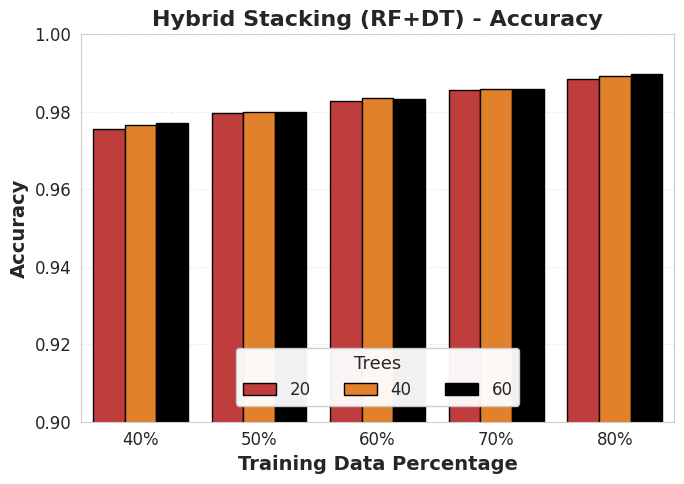

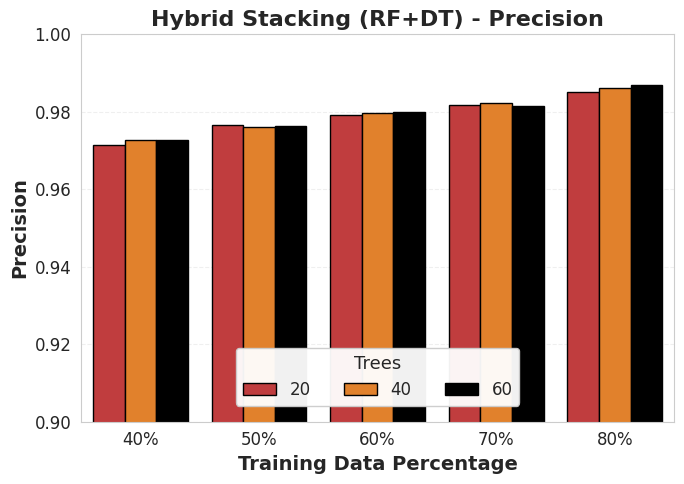

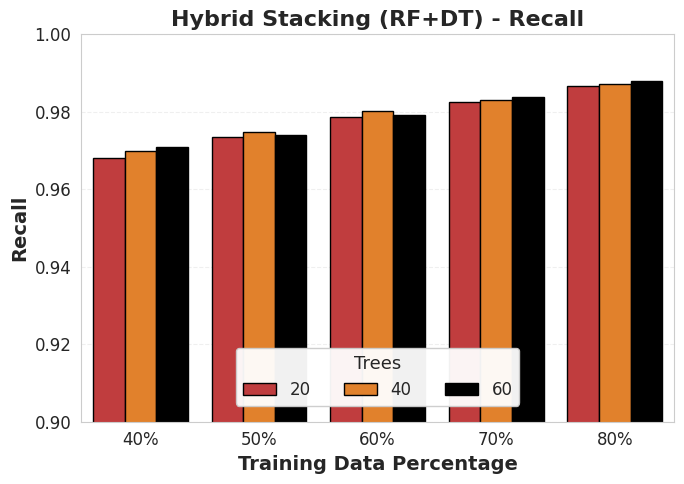

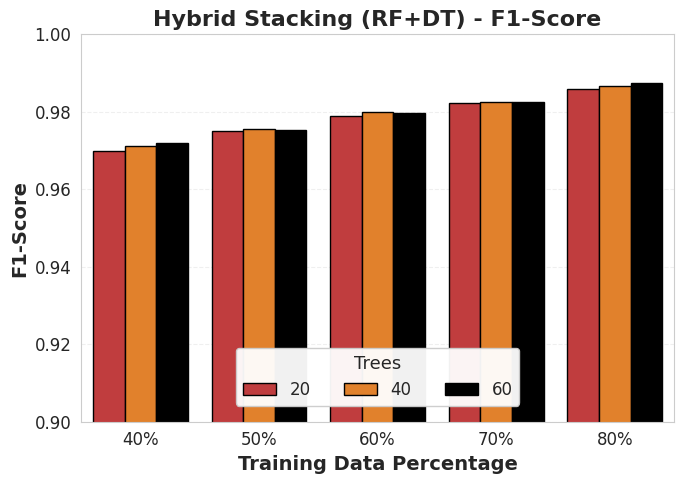


✓ IEEE-optimized plots generated successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("CREATING IEEE-FORMAT BAR PLOTS (HYBRID)")
print("="*80)

# IEEE Style Global Font Settings
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

partition_order = ['40%', '50%', '60%', '70%', '80%']
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Ensure correct order
hybrid_new_df['Data Partition'] = pd.Categorical(
    hybrid_new_df['Data Partition'],
    categories=partition_order,
    ordered=True
)

palette = {
    20: '#D62728',
    40: '#FF7F0E',
    60: '#000000'
}

for metric in metrics_list:

    # IEEE two-column width friendly size
    plt.figure(figsize=(7, 5))

    ax = sns.barplot(
        data=hybrid_new_df,
        x='Data Partition',
        y=metric,
        hue='Trees',
        palette=palette,
        edgecolor='black'
    )

    ax.set_title(
        f'Hybrid Stacking (RF+DT) - {metric}',
        fontweight='bold'
    )

    ax.set_xlabel('Training Data Percentage', fontweight='bold')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_ylim([0.90, 1.0])

    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Increase tick thickness for clarity
    ax.tick_params(axis='both', which='major', width=1.2)

    # Legend bottom center (IEEE clean style)
    ax.legend(
        title='Trees',
        loc='lower center',
        bbox_to_anchor=(0.5, 0.02),
        ncol=3,
        frameon=True,
        framealpha=0.95
    )

    plt.tight_layout()
    plt.savefig(f'hybrid_{metric.lower()}_IEEE.png', dpi=600, bbox_inches='tight')
    plt.show()

print("\n✓ IEEE-optimized plots generated successfully!")

In [ ]:
import os
os.makedirs('pickle', exist_ok=True)

import pickle

# Save the best model (Hybrid Stacking) to a file
pickle.dump(stacking_model, open('pickle/hybrid_stacking_model.pkl', 'wb'))

print("✅ Hybrid Stacking model has been saved successfully to 'pickle/hybrid_stacking_model.pkl'.")
print(f"   Model: Hybrid Stacking (Random Forest + Decision tree)")
print(f"   Accuracy: {hybrid_metrics['Accuracy']:.4f} ({hybrid_metrics['Accuracy']*100:.2f}%)")
print(f"   F1-Score: {hybrid_metrics['F1-Score']:.4f}")
print(f"   Recall: {hybrid_metrics['Recall']:.4f}")
print(f"   Precision: {hybrid_metrics['Precision']:.4f}")

✅ Hybrid Stacking model has been saved successfully to 'pickle/hybrid_stacking_model.pkl'.
   Model: Hybrid Stacking (Random Forest + Decision tree)
   Accuracy: 0.9900 (99.00%)
   F1-Score: 0.9877
   Recall: 0.9883
   Precision: 0.9871
